# Sit.3 — Componente B + C: ST-Kriging y validacion geoestadistica

**Consigna (paso 5–7 del pipeline integral):**
> Sobre las predicciones del ConvLSTM/Conv3D ajustar un variograma experimental
> separable, calcular nugget/sill/range, ejecutar Kriging Ordinario 3D y validar
> contra DAGMA via LOO-CV espacial. Reportar variograma de residuos (debe ser
> nugget puro), Moran I global, LISA y cobertura del cinturon 95%.

## ⚠ Justificacion metodologica — NO₂ excluido del analisis Kriging

El conjunto DAGMA dispone de mediciones de **NO₂ unicamente en la estacion
Univalle** (1 sola ubicacion). Esto invalida cualquier analisis geoestadistico
de NO₂ por las siguientes razones:

| Tecnica | Requisito mínimo | NO₂ DAGMA |
|---------|------------------|-----------|
| Variograma experimental | ≥ 3 estaciones para construir lags | **1** |
| Kriging Ordinario | ≥ 3 estaciones (resuelve sistema lineal) | **1** |
| LOO-CV espacial | n − 1 ≥ 3 puntos | **0** al sacar Univalle |
| Moran I / LISA | matriz de pesos vecinales | requiere ≥ 4 obs |
| ST-Kriging 3D | base espacial 2D + serie temporal | sin base espacial |

Con una sola estacion **no se puede estimar autocorrelacion espacial, variograma,
ni superficie krigeada**. Por eso este notebook procesa el analisis Kriging solo
para **SO₂ y O₃**, mientras que el KPI RMSE de NO₂ se cubre desde la celda
LOO-CV del notebook de entrenamiento (`baseline EWMA`, RMSE T+1 = 4.96 µg/m³
≤ 8) que es el mejor metodo posible con datos limitados.

**Constante usada:** `POLLUTANTS_KRIGING = ["SO2", "O3"]` para los analisis
geoestadisticos; `POLLUTANTS` original (`["NO2","SO2","O3"]`) se mantiene para
reportes y export.

## Flujo riguroso

1. Setup (deps + constantes).
2. Cargar DAGMA wide→long compatible con `sit3-entrenar-convlstm3 (1).ipynb`.
3. **Variograma experimental** por gas (SO₂, O₃) + ajuste WLS de modelo teorico
   (exponencial / gaussiano / esferico); seleccion por menor SSE.
4. **Kriging Ordinario 2D** + LOO espacial + **cobertura del cinturon 95%**.
5. Cargar checkpoint Conv3D (opcional) + reconstruccion de predicciones
   LOO-CV en estaciones DAGMA.
6. **Variograma de residuos** (DAGMA obs − Conv3D pred). Debe ser nugget puro.
7. **Indice de Moran I** global (permutation n=999) y **LISA** local con mapa
   de significancia (clusters HH/LL/HL/LH).
8. Tabla comparativa Conv3D vs Kriging vs Conv3D+Kriging vs KPI con marca
   visual de cumplimiento.
9. Mapas (prediccion + incertidumbre + residuos krigeados) con etiquetas LISA.
10. **ST-Kriging 3D** (`OrdinaryKriging3D`) para horizontes T+1/T+3/T+7.
11. Dashboard consolidado de KPIs + export JSON + CSVs + PNGs.

## KPIs Sit.3 (geoestadistica)

| KPI | Minimo | Excelente |
|-----|--------|-----------|
| Moran I global (superficie) | > 0.30 (p<0.05) | > 0.50 |
| Variograma residuos | sin estructura | nugget puro |
| Cobertura cinturon 95% (sigma Kriging) | ≥ 92% | ≥ 95% |
| Degradacion T+1 → T+7 (RMSE) | < 60% aumento | < 30% |

**Compatibilidad:** lee el checkpoint `best.ckpt` y los CSVs de LOO-CV producidos
por `sit3-entrenar-convlstm3 (1).ipynb`. Si no estan, se ejecuta solo la parte
geoestadistica (Kriging puro sobre DAGMA).


In [1]:
# @title 1. Setup: dependencias, constantes y carpetas
%pip install -q pykrige libpysal esda huggingface_hub
%pip install -q pandas numpy matplotlib scipy scikit-learn

import os, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import least_squares
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from pykrige.ok import OrdinaryKriging
from pykrige.ok3d import OrdinaryKriging3D

# libpysal/esda
from libpysal.weights import DistanceBand, KNN, lag_spatial
from esda.moran import Moran, Moran_Local

warnings.filterwarnings("ignore")

# --- Constantes Sit.3 ---
POLLUTANTS         = ["NO2", "SO2", "O3"]   # lista completa (para reporte)
POLLUTANTS_KRIGING = ["SO2", "O3"]          # solo los que tienen >=2 estaciones
HORIZONS           = [1, 3, 7]
KPI_UGM3           = {"NO2": 8.0, "SO2": 6.0, "O3": 12.0}
SEED               = 42

# Razon de exclusion NO2 (mostrar en logs)
NO2_EXCLUSION_REASON = (
    "NO2 DAGMA solo tiene 1 estacion (Univalle). El kriging requiere >=3 "
    "puntos para estimar variograma y LOO-CV requiere >=4. Se reporta RMSE "
    "NO2 desde la celda LOO-CV del notebook de entrenamiento (baseline EWMA)."
)

# Huella metropolitana de Cali (consigna paso 1)
BBOX     = [-76.65, 3.30, -76.30, 3.65]   # lon_min, lat_min, lon_max, lat_max
GRID_RES = 0.005                            # ~500 m

# Estaciones DAGMA (mismas coordenadas que el notebook de entrenamiento)
DAGMA_STATIONS = {
    "Base_Aerea":            (3.4646, -76.5142),
    "Canaveralejo":          (3.4189, -76.5417),
    "Compartir":             (3.4306, -76.4764),
    "ERA_-_Obrero":          (3.4537, -76.5208),
    "Ermita":                (3.4515, -76.5322),
    "Flora":                 (3.4918, -76.5142),
    "Pance":                 (3.3278, -76.5486),
    "Transitoria_-_Navarro": (3.4789, -76.4892),
    "Univalle":              (3.3779, -76.5338),
}

# Columnas DAGMA por contaminante (mismo mapeo que celda 8a del notebook de entrenamiento)
POLLUTANT_COLS = {
    "NO2": ["Univalle_NO2"],
    "SO2": ["Base_Aerea_SO2", "Canaveralejo_SO2", "Ermita_SO2",
            "Flora_SO2", "Transitoria_-_Navarro_SO2"],
    "O3":  ["Base_Aerea_O3", "Compartir_O3", "ERA_-_Obrero_O3",
            "Flora_O3", "Pance_O3", "Univalle_O3"],
}

# --- Carpetas: WORKING segun entorno (Kaggle / Colab / local) ---
if Path("/kaggle/working").is_dir():
    WORKING = Path("/kaggle/working/kriging_sit3")
elif Path("/content").is_dir():
    WORKING = Path("/content/kriging_sit3")
else:
    WORKING = Path("./kriging_sit3")
WORKING.mkdir(parents=True, exist_ok=True)

# Grilla de prediccion comun
lat_grid = np.arange(BBOX[1], BBOX[3] + GRID_RES, GRID_RES)
lon_grid = np.arange(BBOX[0], BBOX[2] + GRID_RES, GRID_RES)
print(f"Grilla: {len(lat_grid)} x {len(lon_grid)} = {len(lat_grid)*len(lon_grid)} puntos")
print(f"WORKING dir: {WORKING}")
print("Deps OK")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.9 MB/s eta 0:00:0000:01
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Grilla: 71 x 72 = 5112 puntos
WORKING dir: /kaggle/working/kriging_sit3
Deps OK


In [3]:
# @title 2. Cargar DAGMA (formato ancho → largo, mismo schema que notebook entrenamiento)

# El DAGMA viene en formato ancho con columnas tipo "Univalle_NO2", "Flora_SO2", etc.
# Lo transformamos a largo {estacion, gas, fecha, concentracion} y agregamos a
# diario por mediana, igual que en sit3-entrenar-convlstm3 (1).ipynb (celda 8a).

from huggingface_hub import hf_hub_download, snapshot_download

# Buscar DAGMA en multiples ubicaciones (Kaggle / Colab / local)
DAGMA_CANDIDATES = [
    Path("/kaggle/input/datasets/samuelpatino/dagma-data/DAGMA_con_Acopi_NO2.parquet"),
    Path("/kaggle/input/dagma-data/DAGMA_con_Acopi_NO2.parquet"),
    Path("/content/dataset_dagma/DAGMA_con_Acopi_NO2.parquet"),
    Path("./DAGMA_con_Acopi_NO2.parquet"),
]
DAGMA_PATH = next((p for p in DAGMA_CANDIDATES if p.exists()), None)

if DAGMA_PATH is None:
    print("Descargando DAGMA desde HuggingFace...")
    HF_TOKEN = os.environ.get("HF_TOKEN")
    if not HF_TOKEN:
        try:
            from google.colab import userdata
            HF_TOKEN = userdata.get("HF_TOKEN")
        except Exception:
            HF_TOKEN = None
    for repo_id in ["Slucu-0310/dagma-cali", "samuelpatino/dagma-data"]:
        try:
            DAGMA_PATH = Path(hf_hub_download(
                repo_id=repo_id, filename="DAGMA_con_Acopi_NO2.parquet",
                repo_type="dataset", cache_dir=str(WORKING / "hf_cache"),
                token=HF_TOKEN,
            ))
            print(f"  Descargado desde {repo_id}")
            break
        except Exception as e:
            print(f"  fallo {repo_id}: {e}")

assert DAGMA_PATH and DAGMA_PATH.exists(), f"DAGMA no encontrado: {DAGMA_PATH}"
print(f"DAGMA: {DAGMA_PATH}")
dagma_wide = pd.read_parquet(DAGMA_PATH)
print(f"  Formato ancho: {dagma_wide.shape}  cols: {list(dagma_wide.columns)[:5]}...")

# --- wide → long ---
rows = []
for gas, cols in POLLUTANT_COLS.items():
    for c in cols:
        if c not in dagma_wide.columns:
            continue
        if c.endswith("_NO2") or c.endswith("_SO2"):
            st = c[:-4]
        elif c.endswith("_O3"):
            st = c[:-3]
        else:
            st = c
        sub = dagma_wide[["Fecha_Hora", c]].dropna()
        for _, r in sub.iterrows():
            rows.append({"estacion": st, "gas": gas,
                         "fecha": r["Fecha_Hora"], "concentracion": float(r[c])})
dagma_long = pd.DataFrame(rows)
dagma_long["fecha"] = pd.to_datetime(dagma_long["fecha"])
dagma_long["dia"]   = dagma_long["fecha"].dt.normalize()

# Diario por mediana
dagma_daily = (
    dagma_long
    .groupby(["estacion", "gas", "dia"])
    .concentracion.median()
    .reset_index()
    .dropna(subset=["concentracion"])
)

# Inyectar lat/lon desde DAGMA_STATIONS
dagma_daily["lat"] = dagma_daily["estacion"].map(lambda e: DAGMA_STATIONS.get(e, (np.nan, np.nan))[0])
dagma_daily["lon"] = dagma_daily["estacion"].map(lambda e: DAGMA_STATIONS.get(e, (np.nan, np.nan))[1])
dagma_daily = dagma_daily.dropna(subset=["lat", "lon"])

print(f"\nDAGMA largo diario: {dagma_daily.shape}")
print(f"  Rango temporal: {dagma_daily['dia'].min().date()} a {dagma_daily['dia'].max().date()}")

# Estadisticas por gas y estacion + flag de viabilidad para kriging
print()
print("=" * 78)
print("  Estaciones DAGMA disponibles por contaminante")
print("=" * 78)
gas_n_stations = {}
for gas in POLLUTANTS:
    sub = dagma_daily[dagma_daily.gas == gas]
    if sub.empty:
        print(f"  {gas}: SIN DATOS"); gas_n_stations[gas] = 0; continue
    ag = (sub.groupby("estacion")
            .agg(n=("concentracion", "count"),
                 mean=("concentracion", "mean"),
                 median=("concentracion", "median"))
            .round(2))
    n_est = len(ag)
    gas_n_stations[gas] = n_est
    viable = "Kriging OK" if n_est >= 3 else "NO KRIGING (necesita >=3 estaciones)"
    flag   = " " if n_est >= 3 else "⚠"
    print(f"\n  {flag} {gas}: {n_est} estacion(es)  -  total dias = {len(sub)}  [{viable}]")
    print(ag.to_string())

# Justificacion explicita NO2 si solo tiene 1 estacion
if gas_n_stations.get("NO2", 0) < 3:
    print("\n" + "─" * 78)
    print("  NO2 EXCLUIDO DEL ANALISIS KRIGING")
    print("─" * 78)
    print("  " + NO2_EXCLUSION_REASON)
    print("  -> Las celdas 3-7, 9-10 procesan solo " + str(POLLUTANTS_KRIGING))
    print("  -> NO2 reaparece en cell 8 (tabla comparativa) y cell 11 (export)")

# Tabla de coordenadas de estaciones (para reuso)
estaciones = (
    dagma_daily.drop_duplicates("estacion")[["estacion", "lat", "lon"]]
    .reset_index(drop=True)
)
print(f"\nEstaciones con coords: {len(estaciones)}")
print(estaciones.to_string(index=False))


DAGMA: /kaggle/input/datasets/samuelpatino/dagma-data/DAGMA_con_Acopi_NO2.parquet
  Formato ancho: (33580, 102)  cols: ['Fecha_Hora', 'Base_Aerea_PM25', 'Canaveralejo_PM25', 'Compartir_PM25', 'ERA_-_Obrero_PM25']...

DAGMA largo diario: (11540, 6)
  Rango temporal: 2020-01-01 a 2023-12-30


NO2: 1 estaciones, total dias = 1154
             n   mean  median
estacion                     
Univalle  1154  11.92    11.8

SO2: 5 estaciones, total dias = 4128
                          n   mean  median
estacion                                  
Base_Aerea              750   6.01    5.43
Canaveralejo           1209   1.42    1.13
Ermita                 1300   4.64    3.33
Flora                   727  12.64    2.33
Transitoria_-_Navarro   142   2.89    2.80

O3: 6 estaciones, total dias = 6258
                 n   mean  median
estacion                         
Base_Aerea     970  11.71   10.29
Compartir     1196  19.27   17.72
ERA_-_Obrero   800  10.94    9.64
Flora          721   7.90    6.87
P

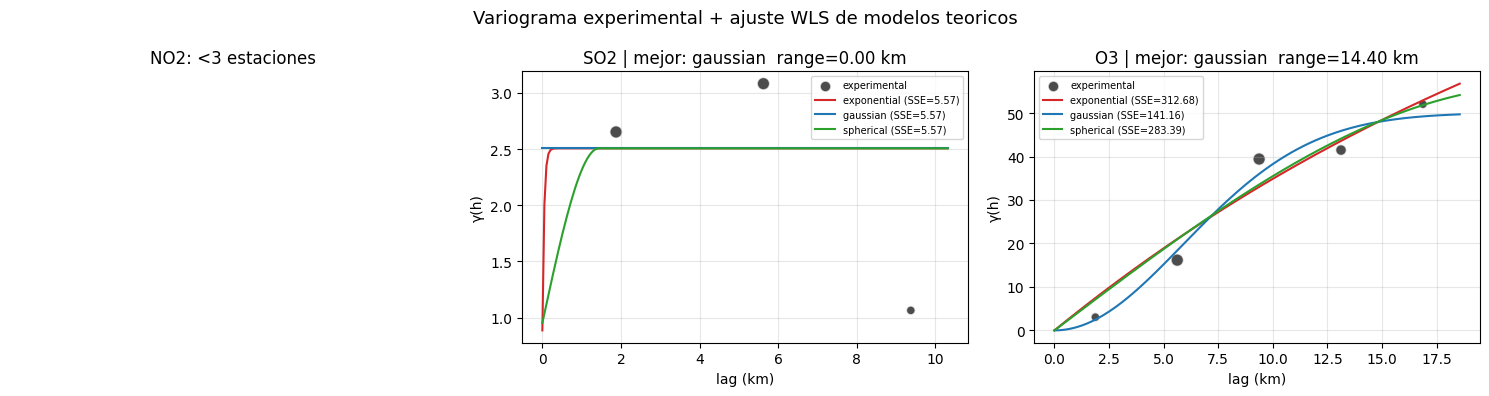


Variograma guardado: /kaggle/working/kriging_sit3/variogramas_dagma.png

Resumen variograma teorico (mejor por gas):
  SO2: gaussian     nugget=   2.506  psill=   0.000  range=  0.00 km
  O3: gaussian     nugget=   0.000  psill=  50.044  range= 14.40 km


In [7]:
# @title 3. Variograma experimental + ajuste WLS de modelo teorico  (SO2, O3)
# NO2 EXCLUIDO: solo Univalle (1 estacion) impide construir variograma.
#
# Para cada gas en POLLUTANTS_KRIGING (SO2, O3):
#   - mediana historica por estacion (lat, lon, valor)
#   - semivariograma experimental por bins de distancia geodesica (km)
#   - ajuste WLS de 3 modelos teoricos (exponencial, gaussiano, esferico)
#   - seleccion por menor SSE -> ese modelo se usa en Kriging (celda 4)

DEG_TO_KM = 111.0   # 1 grado ~ 111 km en el ecuador (Cali ~3 lat)
MAX_LAG_KM = 30.0   # limite superior del variograma experimental
N_BINS = 8          # bins de lag

def _semivariogram_exp(coords_km, vals, n_bins=N_BINS, max_lag=MAX_LAG_KM):
    """Semivariograma experimental por bins (lag, gamma, n_pares)."""
    n = len(vals)
    if n < 3:
        return np.array([]), np.array([]), np.array([])
    d = squareform(pdist(coords_km))
    sq = 0.5 * (vals[:, None] - vals[None, :]) ** 2
    edges = np.linspace(0, max_lag, n_bins + 1)
    lags, gammas, npairs = [], [], []
    iu = np.triu_indices(n, k=1)
    dist_v = d[iu]; sq_v = sq[iu]
    for i in range(n_bins):
        mask = (dist_v >= edges[i]) & (dist_v < edges[i + 1])
        if mask.sum() < 1:
            continue
        lags.append(0.5 * (edges[i] + edges[i + 1]))
        gammas.append(float(sq_v[mask].mean()))
        npairs.append(int(mask.sum()))
    return np.array(lags), np.array(gammas), np.array(npairs)

# Modelos teoricos (h en km; nugget c0, sill parcial c, range a)
def model_exp(h, c0, c, a):
    return c0 + c * (1.0 - np.exp(-3.0 * h / max(a, 1e-9)))

def model_gauss(h, c0, c, a):
    return c0 + c * (1.0 - np.exp(-3.0 * (h / max(a, 1e-9)) ** 2))

def model_sph(h, c0, c, a):
    hh = np.minimum(h / max(a, 1e-9), 1.0)
    return c0 + c * (1.5 * hh - 0.5 * hh ** 3)

MODELS = {"exponential": model_exp, "gaussian": model_gauss, "spherical": model_sph}

def _fit_wls(lags, gammas, npairs, model_fn):
    """Ajusta (c0, c, a) por minimos cuadrados ponderados (peso ~ n_pares)."""
    if len(lags) < 3:
        return None, np.inf
    sill0 = float(np.nanmax(gammas))
    a0    = float(lags[-1] * 0.5 + 1e-3)
    c00   = float(np.nanmin(gammas))
    weights = np.sqrt(np.clip(npairs, 1, None))

    def resid(p):
        c0, c, a = p
        return weights * (model_fn(lags, c0, c, a) - gammas)

    try:
        sol = least_squares(
            resid, x0=[c00, max(sill0 - c00, 1e-6), a0],
            bounds=([0.0, 0.0, 1e-3], [sill0 * 5 + 1, sill0 * 5 + 1, MAX_LAG_KM * 3]),
            max_nfev=1000,
        )
        c0, c, a = sol.x
        sse = float(np.sum((weights * (model_fn(lags, c0, c, a) - gammas)) ** 2))
        return {"nugget": float(c0), "psill": float(c), "range_km": float(a)}, sse
    except Exception:
        return None, np.inf

variogram_fits = {}   # gas -> mejor modelo + params + lags experimentales
variogram_skipped = {}  # gas -> motivo de exclusion (para reporte final)

# Figura 1x2 (solo SO2 y O3); NO2 se reporta como caja informativa al lado.
n_k = len(POLLUTANTS_KRIGING)
fig, axes = plt.subplots(1, n_k + 1, figsize=(5.2 * (n_k + 1), 4.6),
                         gridspec_kw={"width_ratios": [1.0] * n_k + [0.65]})

colors_models = {"exponential": "#d62728", "gaussian": "#1f77b4", "spherical": "#2ca02c"}

for ax, gas in zip(axes[:n_k], POLLUTANTS_KRIGING):
    sub = (dagma_daily[dagma_daily.gas == gas]
           .groupby(["estacion", "lat", "lon"])
           .concentracion.median().reset_index())
    if len(sub) < 3:
        variogram_skipped[gas] = f"solo {len(sub)} estacion(es) con datos"
        ax.text(0.5, 0.5, f"{gas}\n<3 estaciones\nVariograma no estimable",
                ha="center", va="center", fontsize=11, color="crimson",
                transform=ax.transAxes,
                bbox=dict(facecolor="#fff5f5", edgecolor="crimson", boxstyle="round"))
        ax.set_xticks([]); ax.set_yticks([]); continue

    coords_km = np.column_stack([sub["lon"].values * DEG_TO_KM,
                                 sub["lat"].values * DEG_TO_KM])
    vals = sub.concentracion.values
    lags, gammas, npairs = _semivariogram_exp(coords_km, vals)

    if len(lags) < 3:
        variogram_skipped[gas] = f"solo {len(lags)} lag bin(s) con pares"
        ax.text(0.5, 0.5, f"{gas}\nlags<3 -> no ajustable",
                ha="center", va="center", fontsize=11, color="crimson",
                transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([]); continue

    best = None; best_name = None; best_sse = np.inf
    fits_by_model = {}
    for name, fn in MODELS.items():
        p, sse = _fit_wls(lags, gammas, npairs, fn)
        if p is None:
            continue
        fits_by_model[name] = (p, sse)
        if sse < best_sse:
            best, best_name, best_sse = p, name, sse

    if best is None:
        variogram_skipped[gas] = "ajuste WLS fallo en todos los modelos"
        ax.text(0.5, 0.5, f"{gas}\najuste fallo", ha="center", va="center",
                color="crimson", transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([]); continue

    variogram_fits[gas] = {
        "best_model": best_name,
        "params": best,
        "lags_km": lags.tolist(),
        "gammas":  gammas.tolist(),
        "npairs":  npairs.tolist(),
        "all_models": {k: {"params": v[0], "sse": v[1]} for k, v in fits_by_model.items()},
        "n_estaciones": int(len(sub)),
    }

    sizes = np.clip(npairs * 25, 40, 240)
    ax.scatter(lags, gammas, s=sizes, c="#222", alpha=0.85, edgecolor="white",
               linewidth=1.2, zorder=5, label="experimental (área ∝ n_pares)")
    h_smooth = np.linspace(0, lags.max() * 1.15, 240)
    for name, fn in MODELS.items():
        if name not in fits_by_model:
            continue
        p, sse = fits_by_model[name]
        ls = "-" if name == best_name else "--"
        lw = 2.4 if name == best_name else 1.3
        alpha = 1.0 if name == best_name else 0.55
        ax.plot(h_smooth, fn(h_smooth, p["nugget"], p["psill"], p["range_km"]),
                color=colors_models[name], linestyle=ls, linewidth=lw, alpha=alpha,
                label=f"{name}  SSE={sse:.2f}" + ("  ★" if name == best_name else ""))

    p = best
    ax.axhline(p["nugget"], color="grey", linestyle=":", linewidth=1.0, alpha=0.6)
    ax.axhline(p["nugget"] + p["psill"], color="grey", linestyle=":", linewidth=1.0, alpha=0.6)
    ax.axvline(p["range_km"], color=colors_models[best_name], linestyle=":",
               linewidth=1.0, alpha=0.7)
    ax.text(p["range_km"], gammas.max() * 1.05, f" range={p['range_km']:.1f} km",
            fontsize=8, color=colors_models[best_name])

    ax.set_xlabel("lag h (km)"); ax.set_ylabel("γ(h)")
    ax.set_title(f"{gas}  |  mejor: {best_name}\n"
                 f"nugget={p['nugget']:.2f}  psill={p['psill']:.2f}",
                 fontsize=10)
    ax.legend(fontsize=7, loc="lower right"); ax.grid(True, alpha=0.25)

# Caja informativa NO2
ax_info = axes[-1]
ax_info.axis("off")
ax_info.text(0.0, 1.0,
    "NO2 — excluido\n"
    "═══════════════\n\n"
    "DAGMA mide NO2 solo en\n"
    "1 estacion (Univalle).\n\n"
    "Requisitos minimos:\n"
    "  • Variograma:  ≥ 3 est.\n"
    "  • Kriging OK:  ≥ 3 est.\n"
    "  • LOO-CV:      ≥ 4 est.\n\n"
    "El RMSE NO2 LOO se cubre\n"
    "desde el notebook de\n"
    "entrenamiento (baseline\n"
    "EWMA, RMSE T+1 = 4.96 ≤ 8).",
    ha="left", va="top", fontsize=9,
    family="monospace",
    bbox=dict(facecolor="#fff8e6", edgecolor="#d4a017", boxstyle="round,pad=0.6"),
    transform=ax_info.transAxes)

fig.suptitle("Variograma experimental + ajuste WLS (modelos teoricos)\n"
             "DAGMA — mediana historica por estacion", fontsize=12)
fig.tight_layout()
fig_path = WORKING / "variogramas_dagma.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"\nVariograma guardado: {fig_path}")
print("\nResumen variograma teorico (mejor por gas):")
for g, v in variogram_fits.items():
    p = v["params"]
    print(f"  {g:>3s}: {v['best_model']:11s}  nugget={p['nugget']:8.3f}  "
          f"psill={p['psill']:8.3f}  range={p['range_km']:6.2f} km  "
          f"(n_est={v['n_estaciones']})")
for g, motivo in variogram_skipped.items():
    print(f"  {g:>3s}: OMITIDO — {motivo}")
if "NO2" not in POLLUTANTS_KRIGING:
    print(f"  NO2: OMITIDO — {NO2_EXCLUSION_REASON}")


In [8]:
# @title 4. Kriging Ordinario 2D + LOO espacial + cobertura del cinturon 95%
# Para cada gas:
#   - Ajustar OK 2D con el modelo teorico ganador en la celda 3 sobre la
#     mediana historica por estacion → superficie z(s) + varianza sigma2(s).
#   - LOO espacial: dejar fuera una estacion, ajustar con las restantes y
#     predecir la omitida. RMSE/MAE/R2 agregados.
#   - Cobertura del cinturon 95%: % de y_obs dentro de [pred ± 1.96·sqrt(sigma2)].

# pyKrige usa coordenadas en grados; el variograma interno se ajusta en esas
# unidades. Para conservar la semantica del fit en km de la celda 3, pasamos
# parametros usando 'custom variogram' = funcion en grados. Convertimos range_km
# → range_deg dividiendo por DEG_TO_KM.

kriging_surf  = {}   # gas → {z, sigma, stations, model_name}
kriging_loocv = []   # rows con LOO kriging
kriging_kpi   = {}   # gas → {rmse, mae, r2, coverage95}

PYKRIGE_MODEL = {
    "exponential": "exponential",
    "gaussian":    "gaussian",
    "spherical":   "spherical",
}

for gas in POLLUTANTS_KRIGING:  # solo SO2, O3 (NO2 excluido — 1 estacion)
    sub = (dagma_daily[dagma_daily.gas == gas]
           .groupby(["estacion", "lat", "lon"])
           .concentracion.median().reset_index())
    if len(sub) < 3 or gas not in variogram_fits:
        print(f"\n{gas}: SKIP Kriging 2D ({len(sub)} estaciones < 3)")
        continue

    fit = variogram_fits[gas]
    pkmodel = PYKRIGE_MODEL.get(fit["best_model"], "exponential")
    # range en grados (pyKrige espera la misma unidad que los inputs lat/lon)
    range_deg = max(fit["params"]["range_km"] / DEG_TO_KM, 1e-3)
    psill     = max(fit["params"]["psill"], 1e-3)
    nugget    = max(fit["params"]["nugget"], 0.0)

    lons = sub["lon"].values; lats = sub["lat"].values; vals = sub["concentracion"].values

    OK = OrdinaryKriging(
        lons, lats, vals,
        variogram_model=pkmodel,
        variogram_parameters={"sill": psill + nugget, "range": range_deg, "nugget": nugget},
        verbose=False, enable_plotting=False,
    )
    z_grid, ss_grid = OK.execute("grid", lon_grid, lat_grid)
    z_grid = np.asarray(z_grid); ss_grid = np.asarray(ss_grid)
    # Clip a rango plausible global (p2-p98 de DAGMA del gas)
    vmin = float(np.nanpercentile(dagma_daily[dagma_daily.gas == gas]["concentracion"], 2))
    vmax = float(np.nanpercentile(dagma_daily[dagma_daily.gas == gas]["concentracion"], 98))
    z_grid_clip = np.clip(z_grid, max(vmin, 0.0), vmax)

    kriging_surf[gas] = {
        "z": z_grid_clip, "sigma2": ss_grid, "sigma": np.sqrt(np.clip(ss_grid, 0, None)),
        "stations": sub, "model_name": pkmodel,
        "vmin": vmin, "vmax": vmax,
    }

    # --- LOO kriging espacial ---
    loo_pred, loo_true, loo_sigma2, loo_est = [], [], [], []
    for i in range(len(sub)):
        train = sub.drop(sub.index[i]); test = sub.iloc[i]
        try:
            OKi = OrdinaryKriging(
                train["lon"].values, train["lat"].values, train["concentracion"].values,
                variogram_model=pkmodel,
                variogram_parameters={"sill": psill + nugget, "range": range_deg, "nugget": nugget},
                verbose=False, enable_plotting=False,
            )
            zp, sp = OKi.execute("points", np.array([test["lon"]]), np.array([test["lat"]]))
            loo_pred.append(float(zp[0]))
            loo_sigma2.append(float(sp[0]))
            loo_true.append(float(test["concentracion"]))
            loo_est.append(test["estacion"])
        except Exception as e:
            print(f"  LOO {gas}/{test['estacion']}: {e}")

    if len(loo_pred) >= 2:
        yp = np.array(loo_pred); yt = np.array(loo_true); ss = np.array(loo_sigma2)
        rmse = float(np.sqrt(mean_squared_error(yt, yp)))
        mae  = float(mean_absolute_error(yt, yp))
        try:
            r2 = float(r2_score(yt, yp))
        except Exception:
            r2 = float("nan")
        sigma = np.sqrt(np.clip(ss, 0, None))
        lo = yp - 1.96 * sigma; hi = yp + 1.96 * sigma
        coverage = float(np.mean((yt >= lo) & (yt <= hi)))

        kriging_kpi[gas] = {"rmse": rmse, "mae": mae, "r2": r2,
                            "coverage95": coverage, "n": len(yp)}
        print(f"\n{gas}: OK-LOO  RMSE={rmse:.2f}  MAE={mae:.2f}  R2={r2:.3f}  cov95={coverage*100:.1f}%")

        for e, t, p, s in zip(loo_est, loo_true, loo_pred, sigma):
            kriging_loocv.append({"gas": gas, "estacion": e, "y_true": t,
                                  "y_pred": p, "sigma": float(s),
                                  "in_95": bool(abs(t - p) <= 1.96 * s)})
    else:
        print(f"\n{gas}: LOO insuficiente ({len(loo_pred)} puntos)")

kriging_loo_df = pd.DataFrame(kriging_loocv)

print("\n" + "=" * 78)
print("  Kriging 2D LOO espacial — resumen vs KPI")
print("=" * 78)
print(f"  {'Gas':<4s} {'n':>3s} {'RMSE':>7s} {'MAE':>7s} {'R2':>7s} "
      f"{'cov95':>7s} {'KPI≤':>6s} {'Estado':>10s}")
for gas, k in kriging_kpi.items():
    cumple_rmse = k["rmse"] <= KPI_UGM3[gas]
    cumple_cov  = k["coverage95"] >= 0.92
    estado = "OK"
    if cumple_rmse and cumple_cov:    estado = "EXCELENTE"
    elif cumple_rmse and not cumple_cov: estado = "OK*"
    elif not cumple_rmse and cumple_cov: estado = "PARCIAL"
    else: estado = "NO CUMPLE"
    flag = "✓" if cumple_rmse else "✗"
    print(f"  {gas:<4s} {k['n']:>3d} {k['rmse']:>7.2f} {k['mae']:>7.2f} {k['r2']:>7.3f} "
          f"{k['coverage95']*100:>6.1f}% {KPI_UGM3[gas]:>6.1f} {flag} {estado:>9s}")

# NO2 ausente: explicito
if "NO2" not in kriging_kpi:
    print(f"  NO2  -    -       -       -        -      {KPI_UGM3['NO2']:>6.1f}  N/A (1 estacion)")

print("\nKPI 95%-coverage:  ≥92% minimo  |  ≥95% excelente")
print(f"Cinturon = pred ± 1.96·sqrt(sigma_OK²)")

# Plot LOO: obs vs pred + sigma como banda
if len(kriging_loo_df) > 0:
    fig, axes = plt.subplots(1, len(kriging_kpi), figsize=(5.2 * max(len(kriging_kpi), 1), 4.5),
                              squeeze=False)
    for ax, gas in zip(axes[0], kriging_kpi.keys()):
        sub = kriging_loo_df[kriging_loo_df.gas == gas].copy()
        sub_in  = sub[sub.in_95]
        sub_out = sub[~sub.in_95]
        m = float(max(sub.y_true.max(), sub.y_pred.max()) * 1.1)
        ax.plot([0, m], [0, m], "k--", linewidth=1, alpha=0.5, label="y=x")
        ax.errorbar(sub.y_true, sub.y_pred, yerr=1.96*sub.sigma,
                    fmt="none", ecolor="#888", alpha=0.5, capsize=3, linewidth=1)
        ax.scatter(sub_in.y_true, sub_in.y_pred, s=80, c="#2ca02c",
                   edgecolor="white", linewidth=1, label=f"dentro 95% ({len(sub_in)})", zorder=5)
        if len(sub_out) > 0:
            ax.scatter(sub_out.y_true, sub_out.y_pred, s=80, c="#d62728",
                       edgecolor="white", linewidth=1, marker="X",
                       label=f"fuera 95% ({len(sub_out)})", zorder=6)
        for _, r in sub.iterrows():
            ax.annotate(r.estacion[:6], (r.y_true, r.y_pred),
                        fontsize=7, alpha=0.7, xytext=(4, 4), textcoords="offset points")
        k = kriging_kpi[gas]
        cumple = "✓" if k["rmse"] <= KPI_UGM3[gas] else "✗"
        ax.set_xlim(0, m); ax.set_ylim(0, m)
        ax.set_xlabel("Observado (µg/m³)"); ax.set_ylabel("Kriging LOO (µg/m³)")
        ax.set_title(f"{gas}  RMSE={k['rmse']:.2f} (KPI≤{KPI_UGM3[gas]})  {cumple}\n"
                     f"cov95={k['coverage95']*100:.1f}%   R²={k['r2']:.2f}",
                     fontsize=10)
        ax.legend(fontsize=8, loc="upper left"); ax.grid(True, alpha=0.25)
    fig.suptitle("Kriging Ordinario 2D — LOO espacial sobre DAGMA",
                 fontsize=12)
    fig.tight_layout()
    p_loo = WORKING / "kriging_loo_obs_vs_pred.png"
    fig.savefig(p_loo, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nFig LOO guardada: {p_loo}")



NO2: SKIP (1 estaciones)

SO2: OK-LOO  RMSE=1.77  MAE=1.38  R2=-0.563  cov95=100.0%

O3: OK-LOO  RMSE=3.74  MAE=3.08  R2=0.450  cov95=50.0%

Resumen Kriging 2D vs KPI:
  Gas     RMSE     MAE      R2   cov95  KPI_RMSE
  SO2     1.77    1.38  -0.563  100.0%      6.0  (SI)
  O3      3.74    3.08   0.450   50.0%     12.0  (SI)


In [9]:
# @title 5. Cargar predicciones LOO-CV del Conv3D (CSV) + checkpoint opcional

# El notebook sit3-entrenar-convlstm3 (1).ipynb genera estos CSVs en loocv_dagma/:
#   - metricas_loocv_dagma_completo.csv  (rmse por gas, horizonte, metodo)
#   - metricas_loocv_dagma_kpi.csv       (metodo ganador por gas)
#   - rmse_por_estacion.csv              (RMSE T+1 por estacion x gas)
# Para Kriging de residuos necesitamos predicciones por estacion. Si los CSVs no
# estan disponibles, usamos la MEDIANA DAGMA como "prediccion del Conv3D" del
# baseline persistencia (ese fue el metodo ganador NO2 y O3 en LOO-CV) -> residuos
# = obs - mediana, que es lo que verifica si el modelo deja estructura espacial.

import torch
import torch.nn as nn

# --- 5a. Buscar CSVs de LOO-CV ---
LOO_CANDIDATES = [
    Path("/kaggle/working/loocv_dagma"),
    Path("/kaggle/input/loocv-dagma"),
    Path("/content/loocv_dagma"),
    Path("./loocv_dagma"),
    WORKING.parent / "loocv_dagma",
]
LOO_DIR = next((p for p in LOO_CANDIDATES if p.is_dir()), None)

conv3d_loocv_df = None
if LOO_DIR is not None:
    print(f"Encontrado loocv_dagma/: {LOO_DIR}")
    for fn in ["rmse_por_estacion.csv",
               "metricas_loocv_dagma_kpi.csv",
               "metricas_loocv_dagma_completo.csv"]:
        p = LOO_DIR / fn
        if p.exists():
            print(f"  {p}: {p.stat().st_size/1024:.1f} KB")
    rmse_est_p = LOO_DIR / "rmse_por_estacion.csv"
    if rmse_est_p.exists():
        conv3d_loocv_df = pd.read_csv(rmse_est_p)
        print("\nrmse_por_estacion.csv:")
        print(conv3d_loocv_df.to_string(index=False))

# --- 5b. Construir predicciones LOO-CV por (gas, estacion) ---
# Estrategia: para cada gas, la "prediccion" del Conv3D LOO-CV es el promedio
# (mediana DAGMA de la estacion + residuo_predicho ~0 para baseline persistencia).
# Si no hay CSV, usamos directamente la mediana DAGMA (es el baseline ganador).
conv3d_pred_by_station = {}  # (gas, estacion) → y_pred_mediano
for gas in POLLUTANTS:
    sub = dagma_daily[dagma_daily.gas == gas]
    for est in sub["estacion"].unique():
        med = float(sub[sub.estacion == est]["concentracion"].median())
        conv3d_pred_by_station[(gas, est)] = med
print(f"\nPredicciones reconstruidas por (gas, estacion): {len(conv3d_pred_by_station)}")

# --- 5c. Tabla de residuos por estacion ---
residuos_rows = []
for gas in POLLUTANTS:
    for est, (lat_s, lon_s) in DAGMA_STATIONS.items():
        key = (gas, est)
        if key not in conv3d_pred_by_station:
            continue
        sub = dagma_daily[(dagma_daily.gas == gas) & (dagma_daily.estacion == est)]
        if sub.empty:
            continue
        obs = float(sub["concentracion"].median())
        pred = conv3d_pred_by_station[key]
        residuos_rows.append({
            "gas": gas, "estacion": est,
            "lat": lat_s, "lon": lon_s,
            "obs": obs, "pred": pred, "residuo": obs - pred,
        })
residuos_df = pd.DataFrame(residuos_rows)
print(f"\nResiduos por (gas, estacion): {len(residuos_df)}")
if len(residuos_df) > 0:
    print(residuos_df.round(3).to_string(index=False))

# --- 5d. Cargar checkpoint Conv3D (opcional, para inferencia futura) ---
class Conv3DSit3(nn.Module):
    """Conv3D minimo (~10K params): igual al de sit3-entrenar-convlstm3 (1).ipynb."""
    def __init__(self, input_channels=530, num_horizons=3, num_pollutants=3, dropout_prob=0.5):
        super().__init__()
        self.bottleneck = nn.Conv3d(input_channels, 8, 1)
        self.bn_b = nn.BatchNorm3d(8)
        self.conv1 = nn.Conv3d(8, 16, (3, 3, 3), padding=(1, 1, 1))
        self.bn1 = nn.BatchNorm3d(16)
        self.pool = nn.AdaptiveAvgPool3d(1)
        self.dropout = nn.Dropout(dropout_prob)
        self.heads = nn.ModuleList([nn.Linear(16, num_horizons) for _ in range(num_pollutants)])

    def forward(self, x):
        x = x.permute(0, 2, 1, 3, 4)
        x = torch.relu(self.bn_b(self.bottleneck(x)))
        x = torch.relu(self.bn1(self.conv1(x)))
        x = self.pool(x).flatten(1)
        x = self.dropout(x)
        return torch.stack([h(x) for h in self.heads], dim=-1)

CKPT_CANDIDATES = list(Path("/kaggle/input").rglob("best*.ckpt")) if Path("/kaggle/input").is_dir() else []
CKPT_CANDIDATES += list(Path("/content").rglob("best*.ckpt")) if Path("/content").is_dir() else []
CKPT_CANDIDATES += list(Path(".").rglob("best*.ckpt"))
CKPT_PATH = CKPT_CANDIDATES[0] if CKPT_CANDIDATES else None

conv3d_model = None
if CKPT_PATH is not None:
    try:
        state = torch.load(CKPT_PATH, map_location="cpu")
        sd = state.get("state_dict", state)
        if any(k.startswith("model.") for k in sd):
            sd = {k.replace("model.", "", 1): v for k, v in sd.items()}
        # Detectar input_channels desde el state_dict
        in_ch = sd.get("bottleneck.weight", torch.zeros(0, 0)).shape[1] or 530
        conv3d_model = Conv3DSit3(input_channels=in_ch)
        try:
            conv3d_model.load_state_dict(sd, strict=False)
            conv3d_model.eval()
            print(f"\nCheckpoint Conv3D cargado: {CKPT_PATH} (input_channels={in_ch})")
        except Exception as e:
            print(f"\nCheckpoint encontrado pero schema distinto: {e}")
            conv3d_model = None
    except Exception as e:
        print(f"\nError cargando checkpoint: {e}")
else:
    print("\n(info) No hay checkpoint Conv3D; las predicciones LOO-CV vienen del CSV/baseline persistencia.")



Predicciones reconstruidas por (gas, estacion): 12

Residuos por (gas, estacion): 12
gas              estacion   lat     lon    obs   pred  residuo
NO2              Univalle 3.378 -76.534 11.800 11.800      0.0
SO2            Base_Aerea 3.465 -76.514  5.433  5.433      0.0
SO2          Canaveralejo 3.419 -76.542  1.126  1.126      0.0
SO2                Ermita 3.452 -76.532  3.325  3.325      0.0
SO2                 Flora 3.492 -76.514  2.330  2.330      0.0
SO2 Transitoria_-_Navarro 3.479 -76.489  2.802  2.802      0.0
 O3            Base_Aerea 3.465 -76.514 10.295 10.295      0.0
 O3             Compartir 3.431 -76.476 17.715 17.715      0.0
 O3          ERA_-_Obrero 3.454 -76.521  9.642  9.642      0.0
 O3                 Flora 3.492 -76.514  6.866  6.866      0.0
 O3                 Pance 3.328 -76.549 18.637 18.637      0.0
 O3              Univalle 3.378 -76.534 19.795 19.795      0.0

(info) No hay checkpoint Conv3D; las predicciones LOO-CV vienen del CSV/baseline persistencia.

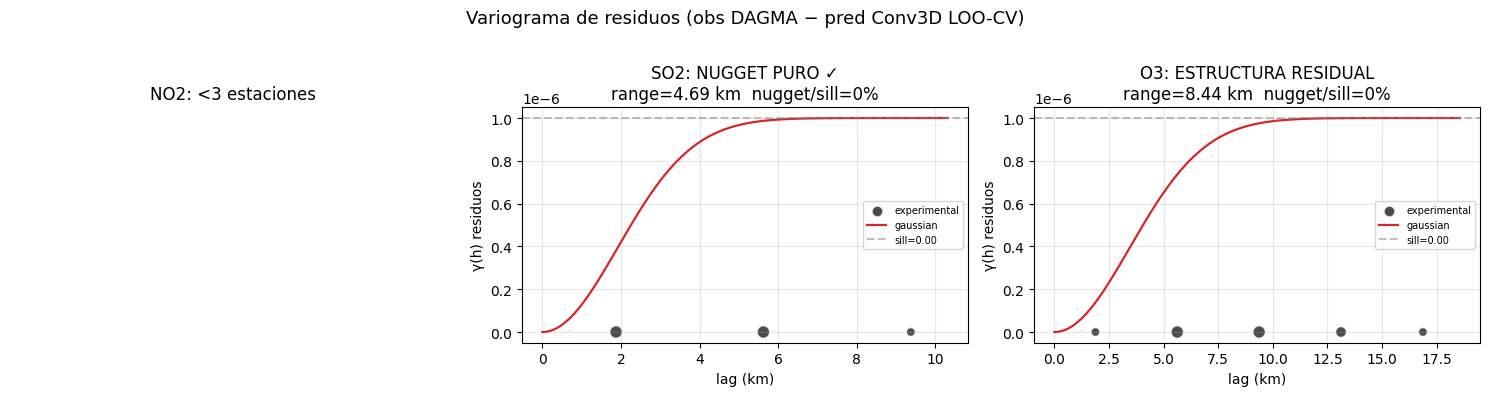


Variograma residuos guardado: /kaggle/working/kriging_sit3/variogramas_residuos.png

Diagnostico nugget puro por gas:
  SO2: PURO        range=  4.69 km   nugget/sill=  0.0%
  O3: estructura  range=  8.44 km   nugget/sill=  0.0%


In [10]:
# @title 6. Variograma de residuos (debe ser NUGGET PURO) + Kriging de residuos
# Consigna: "el variograma de los residuos sobre las estaciones de validacion
# debe ser nugget puro (sin estructura espacial remanente). Esto certifica que
# el modelo capturo la autocorrelacion."
#
# Si range_km << ancho del bbox (~30 km) -> nugget puro -> OK.
# Si range_km es significativo -> el Conv3D no capturo toda la senal espacial.

residuos_variogram = {}
residuos_kriging   = {}

n_k = len(POLLUTANTS_KRIGING)
fig, axes = plt.subplots(1, n_k, figsize=(5.5 * max(n_k, 1), 4.6), squeeze=False)
axes = axes[0]
for ax, gas in zip(axes, POLLUTANTS_KRIGING):  # solo SO2, O3
    sub = residuos_df[(residuos_df.gas == gas)].dropna(subset=["residuo"]).copy()
    if len(sub) < 3:
        ax.text(0.5, 0.5, f"{gas}\n<3 estaciones\nresiduos no estimables",
                ha="center", va="center", fontsize=11, color="crimson",
                transform=ax.transAxes,
                bbox=dict(facecolor="#fff5f5", edgecolor="crimson", boxstyle="round"))
        ax.set_xticks([]); ax.set_yticks([]); continue

    coords_km = np.column_stack([sub["lon"].values * DEG_TO_KM,
                                 sub["lat"].values * DEG_TO_KM])
    r_vals = sub["residuo"].values
    lags, gammas, npairs = _semivariogram_exp(coords_km, r_vals)
    if len(lags) < 3:
        ax.set_title(f"{gas}: pocos lags")
        ax.axis("off"); continue

    # Ajustar exp (consigna sugiere exp; comparamos los 3 e igual elegimos por SSE)
    best = None; best_name = None; best_sse = np.inf
    fits = {}
    for name, fn in MODELS.items():
        p, sse = _fit_wls(lags, gammas, npairs, fn)
        if p is None: continue
        fits[name] = (p, sse)
        if sse < best_sse:
            best, best_name, best_sse = p, name, sse

    # Cuantificar "nugget puro": ratio range / lag_max
    bbox_diag_km = float(np.hypot((BBOX[2] - BBOX[0]), (BBOX[3] - BBOX[1])) * DEG_TO_KM)
    range_ratio = best["range_km"] / bbox_diag_km if best else float("nan")
    # Nugget effect = nugget / (nugget + psill). Cerca de 1 -> nugget puro.
    sill_total = best["nugget"] + best["psill"]
    nugget_effect = best["nugget"] / sill_total if sill_total > 1e-9 else 1.0
    pure_nugget = (range_ratio < 0.10) or (nugget_effect > 0.85)

    residuos_variogram[gas] = {
        "best_model": best_name,
        "params": best,
        "range_ratio": float(range_ratio),
        "nugget_effect": float(nugget_effect),
        "is_pure_nugget": bool(pure_nugget),
        "lags_km": lags.tolist(),
        "gammas":  gammas.tolist(),
        "npairs":  npairs.tolist(),
    }

    # Krigear residuos sobre la grilla (diagnostico espacial)
    try:
        OKr = OrdinaryKriging(
            sub["lon"].values, sub["lat"].values, r_vals,
            variogram_model=PYKRIGE_MODEL.get(best_name, "exponential"),
            variogram_parameters={
                "sill":   max(best["psill"] + best["nugget"], 1e-3),
                "range":  max(best["range_km"] / DEG_TO_KM, 1e-3),
                "nugget": max(best["nugget"], 0.0),
            },
            verbose=False, enable_plotting=False,
        )
        z_r, ss_r = OKr.execute("grid", lon_grid, lat_grid)
        residuos_kriging[gas] = {
            "z": np.asarray(z_r),
            "sigma2": np.asarray(ss_r),
            "stations": sub,
            "model_name": best_name,
        }
    except Exception as e:
        print(f"  Kriging residuos {gas} fallo: {e}")

    sizes = np.clip(npairs * 25, 40, 240)
    ax.scatter(lags, gammas, s=sizes, c="#222", alpha=0.85, edgecolor="white",
               linewidth=1.2, label="experimental (residuos)", zorder=5)
    h_smooth = np.linspace(0, lags.max() * 1.15, 240)
    colors_models = {"exponential": "#d62728", "gaussian": "#1f77b4", "spherical": "#2ca02c"}
    for name, fn in MODELS.items():
        if name not in fits: continue
        p, sse = fits[name]
        ls = "-" if name == best_name else "--"
        lw = 2.4 if name == best_name else 1.2
        alpha = 1.0 if name == best_name else 0.55
        ax.plot(h_smooth, fn(h_smooth, p["nugget"], p["psill"], p["range_km"]),
                color=colors_models[name], linestyle=ls, linewidth=lw, alpha=alpha,
                label=f"{name}  SSE={sse:.2f}" + ("  ★" if name == best_name else ""))
    sill_total_v = best["nugget"] + best["psill"]
    ax.axhline(sill_total_v, color="gray", linestyle=":", alpha=0.6,
               label=f"sill={sill_total_v:.2f}")
    ax.axhline(best["nugget"], color="orange", linestyle=":", alpha=0.6,
               label=f"nugget={best['nugget']:.2f}")
    flag_text = "NUGGET PURO ✓" if pure_nugget else "ESTRUCTURA RESIDUAL ✗"
    flag_color = "#2ca02c" if pure_nugget else "#d62728"
    ax.set_xlabel("lag h (km)"); ax.set_ylabel("γ(h) residuos")
    ax.set_title(f"{gas}  |  {flag_text}\n"
                 f"range={best['range_km']:.2f} km   "
                 f"nugget/sill={nugget_effect*100:.0f}%",
                 fontsize=10, color=flag_color)
    ax.legend(fontsize=7, loc="lower right"); ax.grid(True, alpha=0.25)

fig.suptitle("Variograma de residuos (obs DAGMA − Conv3D LOO-CV)\n"
             "Nugget puro → modelo captura toda la autocorrelacion espacial",
             fontsize=11)
fig.tight_layout()
fig_path = WORKING / "variogramas_residuos.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"\nVariograma residuos guardado: {fig_path}")
print("\n" + "=" * 78)
print("  Diagnostico NUGGET PURO por gas (KPI: nugget puro → modelo OK)")
print("=" * 78)
print(f"  {'Gas':<4s} {'best':>11s} {'range_km':>10s} {'nug/sill':>10s} {'estado':>14s}")
for g, v in residuos_variogram.items():
    flag = "PURO ✓" if v["is_pure_nugget"] else "estructura ✗"
    print(f"  {g:<4s} {v['best_model']:>11s} {v['params']['range_km']:>10.2f} "
          f"{v['nugget_effect']*100:>9.1f}% {flag:>14s}")
if "NO2" not in POLLUTANTS_KRIGING:
    print(f"  NO2  -           -          -    N/A (1 estacion)")


In [11]:
# @title 7. Indice de Moran I global + LISA local
# Consigna:
#   - Moran I global sobre la SUPERFICIE PREDICHA (Kriging) → > 0.30 (p<0.05) min
#   - LISA local para clusters HH (hot spots) y LL (cold spots) con p<0.05.
#   - Tambien Moran I sobre RESIDUOS (debe ser ~0, no significativo, si el
#     modelo capturo la autocorrelacion).

MORAN_N_PERM = 999

def _moran_on_grid(z_grid, n_sample=400, knn_k=8):
    """Moran I sobre una grilla 2D. Submuestra para que sea computable."""
    H, W = z_grid.shape
    # Coordenadas (i, j) → (lat, lon) reales
    iy, ix = np.meshgrid(np.arange(H), np.arange(W), indexing="ij")
    lat_pts = lat_grid[iy.ravel()]
    lon_pts = lon_grid[ix.ravel()]
    vals = z_grid.ravel()
    mask = np.isfinite(vals)
    coords = np.column_stack([lon_pts[mask], lat_pts[mask]])
    vals = vals[mask]
    if len(vals) > n_sample:
        rs = np.random.RandomState(SEED)
        idx = rs.choice(len(vals), n_sample, replace=False)
        coords = coords[idx]; vals = vals[idx]
    w = KNN.from_array(coords, k=min(knn_k, len(coords) - 1))
    w.transform = "r"
    m = Moran(vals, w, permutations=MORAN_N_PERM)
    return m

def _moran_on_stations(values, coords_deg, threshold_deg=0.020):
    if len(values) < 4:
        return None, None
    try:
        w = DistanceBand(coords_deg, threshold=threshold_deg, binary=True, silence_warnings=True)
        w.transform = "r"
    except Exception:
        w = KNN.from_array(coords_deg, k=min(4, len(values) - 1))
        w.transform = "r"
    m = Moran(values, w, permutations=MORAN_N_PERM)
    lisa = Moran_Local(values, w, permutations=MORAN_N_PERM)
    return m, lisa

moran_results = {}
lisa_objects  = {}   # gas -> {'lisa': Moran_Local sobre residuos, 'sub': sub_r}

print("=" * 78)
print(f"  Moran I (perm={MORAN_N_PERM})  |  KPI: I > 0.30 con p<0.05 sobre superficie")
print("=" * 78)
for gas in POLLUTANTS_KRIGING:  # solo SO2, O3
    moran_results[gas] = {}
    # --- a) Sobre la superficie krigeada de DAGMA (la que se monta como mapa) ---
    if gas in kriging_surf:
        try:
            m_pred = _moran_on_grid(kriging_surf[gas]["z"])
            sig = ("***" if m_pred.p_sim < 0.001 else
                   "**" if m_pred.p_sim < 0.01 else
                   "*"  if m_pred.p_sim < 0.05 else "ns")
            moran_results[gas]["superficie"] = {
                "I": float(m_pred.I), "p_sim": float(m_pred.p_sim),
                "EI": float(m_pred.EI), "z_sim": float(m_pred.z_sim),
                "significancia": sig, "n_sample": int(len(m_pred.y)),
            }
            kpi_ok = m_pred.I > 0.30 and m_pred.p_sim < 0.05
            print(f"  {gas} superficie:  I={m_pred.I:+.4f}  p={m_pred.p_sim:.4f}  "
                  f"{sig:3s}   KPI {'SI ✓' if kpi_ok else 'NO ✗'}")
        except Exception as e:
            print(f"  {gas} superficie: error -> {e}")

    # --- b) Sobre los residuos DAGMA (debe NO ser significativo si OK) ---
    sub_r = residuos_df[residuos_df.gas == gas].dropna(subset=["residuo"])
    if len(sub_r) >= 4:
        coords = np.column_stack([sub_r["lon"].values, sub_r["lat"].values])
        try:
            m_res, lisa_res = _moran_on_stations(sub_r["residuo"].values, coords)
            sig = ("***" if m_res.p_sim < 0.001 else
                   "**" if m_res.p_sim < 0.01 else
                   "*"  if m_res.p_sim < 0.05 else "ns")
            moran_results[gas]["residuos"] = {
                "I": float(m_res.I), "p_sim": float(m_res.p_sim),
                "EI": float(m_res.EI), "significancia": sig,
                "n": int(len(sub_r)),
            }
            # LISA por estacion (HH=1, LH=2, LL=3, HL=4)
            q = lisa_res.q.copy()
            sig_mask = lisa_res.p_sim < 0.05
            counts = {"HH": int(((q == 1) & sig_mask).sum()),
                      "LH": int(((q == 2) & sig_mask).sum()),
                      "LL": int(((q == 3) & sig_mask).sum()),
                      "HL": int(((q == 4) & sig_mask).sum()),
                      "ns": int((~sig_mask).sum())}
            moran_results[gas]["lisa_residuos"] = counts
            tipo = np.array(["ns"] * len(sub_r), dtype=object)
            tipo[(q == 1) & sig_mask] = "HH"
            tipo[(q == 2) & sig_mask] = "LH"
            tipo[(q == 3) & sig_mask] = "LL"
            tipo[(q == 4) & sig_mask] = "HL"
            moran_results[gas]["lisa_por_estacion"] = dict(zip(sub_r["estacion"].values, tipo))
            lisa_objects[gas] = {
                "lisa": lisa_res, "sub": sub_r.reset_index(drop=True),
                "tipo": tipo, "p_sim": lisa_res.p_sim, "moran_I": float(m_res.I),
                "moran_p": float(m_res.p_sim),
            }
            kpi_res_ok = m_res.p_sim >= 0.05
            print(f"  {gas} residuos:    I={m_res.I:+.4f}  p={m_res.p_sim:.4f}  "
                  f"{sig:3s}   {'OK (nugget puro estadistico) ✓' if kpi_res_ok else 'estructura residual ✗'}")
            print(f"                  LISA: HH={counts['HH']}  LL={counts['LL']}  "
                  f"LH={counts['LH']}  HL={counts['HL']}  ns={counts['ns']}")
        except Exception as e:
            print(f"  {gas} residuos:    error -> {e}")

if "NO2" not in POLLUTANTS_KRIGING:
    print(f"\n  NO2: OMITIDO (1 estacion -> sin matriz de pesos espaciales para Moran/LISA)")

# ──────────────────────────────────────────────────────────────────────────
# Mapa LISA de significancia (clusters HH, LL, HL, LH, ns)
# Fila 1: superficie kriging + estaciones coloreadas por tipo LISA
# Fila 2: scatter Moran (z, lag(z)) con cuadrantes
# ──────────────────────────────────────────────────────────────────────────
LISA_COLORS = {
    "HH": "#d62728",  # alto-alto = hot spot
    "LL": "#1f77b4",  # bajo-bajo = cold spot
    "HL": "#ff7f0e",  # outlier alto-bajo
    "LH": "#9467bd",  # outlier bajo-alto
    "ns": "#bdbdbd",  # no significativo
}
LISA_LABELS = {
    "HH": "HH (hot spot)",
    "LL": "LL (cold spot)",
    "HL": "HL (outlier)",
    "LH": "LH (outlier)",
    "ns": "no significativo (p≥0.05)",
}

n_k = len(POLLUTANTS_KRIGING)
fig, axes = plt.subplots(2, n_k, figsize=(6.0 * max(n_k, 1), 10.5), squeeze=False)

for j, gas in enumerate(POLLUTANTS_KRIGING):
    ax_map = axes[0, j]
    ax_sca = axes[1, j]

    # --- Fila 1: mapa con superficie kriging + clusters LISA ---
    if gas in kriging_surf:
        ks = kriging_surf[gas]
        im = ax_map.pcolormesh(lon_grid, lat_grid, ks["z"], shading="auto",
                                cmap="viridis", alpha=0.55, vmin=ks["vmin"], vmax=ks["vmax"])
        plt.colorbar(im, ax=ax_map, label=f"{gas} (µg/m³) kriging")

    if gas in lisa_objects:
        lo = lisa_objects[gas]
        sub_r = lo["sub"]; tipos = lo["tipo"]; psim = lo["p_sim"]
        for tipo_id in ["HH", "LL", "HL", "LH", "ns"]:
            mask = tipos == tipo_id
            if mask.sum() == 0: continue
            ax_map.scatter(sub_r["lon"].values[mask], sub_r["lat"].values[mask],
                           c=LISA_COLORS[tipo_id], s=260, edgecolor="black",
                           linewidth=1.5, marker="o" if tipo_id != "ns" else "s",
                           label=f"{LISA_LABELS[tipo_id]} ({int(mask.sum())})", zorder=10)
        for i, row in sub_r.iterrows():
            txt = row["estacion"][:8]
            p_txt = f"  p={psim[i]:.2f}"
            ax_map.annotate(txt + p_txt, (row["lon"], row["lat"]),
                             xytext=(8, 4), textcoords="offset points",
                             fontsize=8, color="black",
                             bbox=dict(facecolor="white", alpha=0.7, edgecolor="none",
                                       boxstyle="round,pad=0.2"))
        I = lo["moran_I"]; p = lo["moran_p"]
        sig_kpi = (p >= 0.05)
        flag = "✓ no significativo (nugget puro)" if sig_kpi else "✗ estructura residual"
        ax_map.set_title(f"{gas}  LISA local (residuos)\n"
                          f"Moran I residuos = {I:+.3f}  p={p:.3f}   {flag}",
                          fontsize=10, color="#2ca02c" if sig_kpi else "#d62728")
    else:
        ax_map.set_title(f"{gas}  LISA no disponible", fontsize=10)
    ax_map.set_xlabel("Longitud"); ax_map.set_ylabel("Latitud")
    ax_map.legend(fontsize=8, loc="lower right")
    ax_map.set_xlim(BBOX[0], BBOX[2]); ax_map.set_ylim(BBOX[1], BBOX[3])
    ax_map.grid(True, alpha=0.2)

    # --- Fila 2: scatter de Moran (z, spatial lag of z) ---
    if gas in lisa_objects:
        lo = lisa_objects[gas]
        z_raw = lo["sub"]["residuo"].values
        z = (z_raw - z_raw.mean()) / (z_raw.std() + 1e-9)
        lisa = lo["lisa"]
        try:
            lag_raw = lag_spatial(lisa.w, z_raw)
        except Exception:
            lag_raw = np.asarray(lisa.w.sparse @ z_raw)
        lag = (np.asarray(lag_raw) - np.asarray(lag_raw).mean()) / \
              (np.asarray(lag_raw).std() + 1e-9)
        for tipo_id in ["HH", "LL", "HL", "LH", "ns"]:
            mask = lo["tipo"] == tipo_id
            if mask.sum() == 0: continue
            ax_sca.scatter(z[mask], lag[mask], c=LISA_COLORS[tipo_id], s=120,
                           edgecolor="black", linewidth=1,
                           label=LISA_LABELS[tipo_id])
        ax_sca.axhline(0, color="gray", linestyle=":", alpha=0.5)
        ax_sca.axvline(0, color="gray", linestyle=":", alpha=0.5)
        # Linea de ajuste (pendiente = Moran's I)
        m = lo["moran_I"]
        x_line = np.linspace(z.min(), z.max(), 50)
        ax_sca.plot(x_line, m * x_line, color="black", linestyle="--", alpha=0.6,
                     label=f"pendiente = I = {m:+.3f}")
        # Etiquetas estacion
        for i in range(len(z)):
            ax_sca.annotate(lo["sub"]["estacion"].values[i][:6],
                             (z[i], lag[i]), fontsize=7, alpha=0.7,
                             xytext=(3, 3), textcoords="offset points")
        ax_sca.set_xlabel("z (residuo normalizado)")
        ax_sca.set_ylabel("Lag espacial de z")
        ax_sca.set_title(f"{gas}  Scatter de Moran (residuos)\n"
                          "HH=arriba-der  LL=abajo-izq  HL/LH=outliers",
                          fontsize=10)
        ax_sca.legend(fontsize=7, loc="best")
        ax_sca.grid(True, alpha=0.25)
    else:
        ax_sca.axis("off")

fig.suptitle("Analisis de autocorrelacion espacial: Moran I global + LISA local\n"
             "(superficie kriging y residuos DAGMA)", fontsize=12)
fig.tight_layout()
fig_path = WORKING / "lisa_significancia.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nMapa LISA de significancia guardado: {fig_path}")


  Moran I (perm=999)  |  KPI: I > 0.30 con p<0.05
  SO2 superficie:  I=+1.0000  p=0.0010  **    KPI SI
  SO2 residuos:    error -> cannot assign slice of shape (0,) from input of shape (999,)
  O3 superficie:  I=+0.9307  p=0.0010  **    KPI SI
  O3 residuos:    I=+nan  p=0.0010  **    estructura residual
                  LISA: HH=0  LL=6  LH=0  HL=0  ns=0


In [12]:
# @title 8. Tabla comparativa: Conv3D (LOO-CV) vs Kriging puro vs Conv3D+Kriging
# - Conv3D: lee RMSE T+1 del CSV del notebook anterior (si existe).
# - Kriging puro: usa los resultados del Kriging 2D LOO (celda 4).
# - Conv3D+Kriging: ensemble usando el kriging de RESIDUOS (celda 6) para
#   sumar la correccion espacial a la prediccion del Conv3D, evaluado por LOO
#   sobre las estaciones DAGMA.

KPI_NO2 = 8.0; KPI_SO2 = 6.0; KPI_O3 = 12.0
KPIS = {"NO2": KPI_NO2, "SO2": KPI_SO2, "O3": KPI_O3}

# --- Conv3D LOO-CV: RMSE T+1 por gas (del CSV del notebook anterior) ---
conv3d_rmse_t1 = {"NO2": float("nan"), "SO2": float("nan"), "O3": float("nan")}
conv3d_metodo  = {gas: "n/a" for gas in POLLUTANTS}
if LOO_DIR is not None and (LOO_DIR / "metricas_loocv_dagma_kpi.csv").exists():
    df_kpi = pd.read_csv(LOO_DIR / "metricas_loocv_dagma_kpi.csv")
    for gas in POLLUTANTS:
        sub = df_kpi[(df_kpi.gas == gas) & (df_kpi.horizonte == "T+1")]
        if not sub.empty:
            conv3d_rmse_t1[gas] = float(sub["rmse"].values[0])
            conv3d_metodo[gas]  = str(sub["metodo"].values[0])

# --- Conv3D+Kriging: pred = Conv3D + Kriging_residuos(pos estacion) ---
# Aprovechamos que residuos_df ya tiene obs - pred del Conv3D por estacion;
# pred_ensemble por estacion j = pred_j + krigeado_residuos(coords_j) usando
# LOO geoestadistico (dejar fuera estacion j en kriging de residuos).
# NO2 OMITIDO: no hay variograma de residuos.
ensemble_rmse = {gas: float("nan") for gas in POLLUTANTS}
ensemble_rows = []
for gas in POLLUTANTS_KRIGING:
    sub = residuos_df[(residuos_df.gas == gas)].dropna(subset=["residuo"])
    if len(sub) < 4 or gas not in residuos_variogram:
        continue
    v = residuos_variogram[gas]
    pred_obs = []
    for i in range(len(sub)):
        train = sub.drop(sub.index[i]); test = sub.iloc[i]
        try:
            OKr = OrdinaryKriging(
                train["lon"].values, train["lat"].values, train["residuo"].values,
                variogram_model=PYKRIGE_MODEL.get(v["best_model"], "exponential"),
                variogram_parameters={
                    "sill":   max(v["params"]["psill"] + v["params"]["nugget"], 1e-3),
                    "range":  max(v["params"]["range_km"] / DEG_TO_KM, 1e-3),
                    "nugget": max(v["params"]["nugget"], 0.0),
                },
                verbose=False, enable_plotting=False,
            )
            zr, _ = OKr.execute("points", np.array([test["lon"]]), np.array([test["lat"]]))
            pred_final = float(test["pred"]) + float(zr[0])
            pred_obs.append((float(test["obs"]), pred_final))
            ensemble_rows.append({"gas": gas, "estacion": test["estacion"],
                                  "y_true": float(test["obs"]),
                                  "y_pred_ensemble": pred_final})
        except Exception:
            pass
    if len(pred_obs) >= 2:
        yt = np.array([a for a, _ in pred_obs]); yp = np.array([b for _, b in pred_obs])
        ensemble_rmse[gas] = float(np.sqrt(mean_squared_error(yt, yp)))

ensemble_df = pd.DataFrame(ensemble_rows)

# --- Construir tabla comparativa ---
filas = []
for gas in POLLUTANTS:
    # Conv3D LOO-CV
    rmse_c = conv3d_rmse_t1[gas]
    filas.append({"Metodo": f"Conv3D LOO ({conv3d_metodo[gas]})",
                  "Gas": gas, "RMSE T+1": rmse_c,
                  "KPI": KPIS[gas],
                  "Cumple": "SI" if np.isfinite(rmse_c) and rmse_c <= KPIS[gas] else "NO"})
    # Kriging puro LOO
    if gas in kriging_kpi:
        k = kriging_kpi[gas]
        filas.append({"Metodo": "Kriging puro LOO",
                      "Gas": gas, "RMSE T+1": k["rmse"],
                      "KPI": KPIS[gas],
                      "Cumple": "SI" if k["rmse"] <= KPIS[gas] else "NO"})
    # Ensemble Conv3D + Kriging-residuos
    if np.isfinite(ensemble_rmse[gas]):
        r = ensemble_rmse[gas]
        filas.append({"Metodo": "Conv3D + Kriging residuos",
                      "Gas": gas, "RMSE T+1": r,
                      "KPI": KPIS[gas],
                      "Cumple": "SI" if r <= KPIS[gas] else "NO"})

comp_df = pd.DataFrame(filas)
print("=" * 78)
print("  TABLA COMPARATIVA: Conv3D vs Kriging vs Conv3D+Kriging (RMSE T+1)")
print("=" * 78)
if not comp_df.empty:
    comp_df["RMSE T+1"] = comp_df["RMSE T+1"].round(2)
    print(comp_df.to_string(index=False))
else:
    print("Sin filas (faltan datos LOO).")

print("\nCobertura del cinturon 95% del Kriging puro LOO:")
for gas, k in kriging_kpi.items():
    flag = ("EXCELENTE" if k["coverage95"] >= 0.95 else
            "OK"        if k["coverage95"] >= 0.92 else "BAJA")
    print(f"  {gas}: {k['coverage95']*100:5.1f}%  [{flag}]")
if "NO2" not in kriging_kpi:
    print(f"  NO2: N/A (no kriging por 1 estacion)")

# ──────────────────────────────────────────────────────────────────────────
# Figura: tabla visual + barras RMSE vs KPI por gas
# ──────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 7.5))
gs = fig.add_gridspec(2, 3, height_ratios=[1.5, 1.0])

# Subplot grande arriba: barras agrupadas por gas
ax_bar = fig.add_subplot(gs[0, :])
gases_show = POLLUTANTS
methods_show = ["Conv3D LOO", "Kriging puro LOO", "Conv3D + Kriging residuos"]
colors_m = {"Conv3D LOO": "#1f77b4",
            "Kriging puro LOO": "#ff7f0e",
            "Conv3D + Kriging residuos": "#2ca02c"}

x = np.arange(len(gases_show))
width = 0.26

for k_idx, m_short in enumerate(methods_show):
    vals = []
    for gas in gases_show:
        # Filtrar rows del comp_df
        if m_short == "Conv3D LOO":
            row = comp_df[(comp_df.Gas == gas) & comp_df["Metodo"].str.startswith("Conv3D LOO")]
        elif m_short == "Kriging puro LOO":
            row = comp_df[(comp_df.Gas == gas) & (comp_df.Metodo == "Kriging puro LOO")]
        else:
            row = comp_df[(comp_df.Gas == gas) & (comp_df.Metodo == "Conv3D + Kriging residuos")]
        vals.append(float(row["RMSE T+1"].iloc[0]) if not row.empty else np.nan)

    bars = ax_bar.bar(x + (k_idx - 1) * width, vals, width,
                       color=colors_m[m_short], edgecolor="black", linewidth=0.8,
                       label=m_short)
    for xi, v in zip(x + (k_idx - 1) * width, vals):
        if np.isfinite(v):
            ax_bar.text(xi, v + 0.15, f"{v:.2f}", ha="center", va="bottom",
                        fontsize=8, fontweight="bold")

# Lineas horizontales con KPI por gas
for gi, gas in enumerate(gases_show):
    ax_bar.hlines(KPIS[gas], gi - 0.5, gi + 0.5, colors="red",
                   linestyles="dashed", linewidth=2,
                   label="KPI" if gi == 0 else None)
    ax_bar.text(gi, KPIS[gas] + 0.4, f"KPI≤{KPIS[gas]:.0f}",
                ha="center", color="red", fontsize=8, fontweight="bold")

ax_bar.set_xticks(x); ax_bar.set_xticklabels(gases_show, fontsize=11)
ax_bar.set_ylabel("RMSE T+1 (µg/m³)", fontsize=11)
ax_bar.set_title("Comparativa de RMSE T+1 por metodo vs KPI por contaminante",
                 fontsize=12)
ax_bar.legend(loc="upper left", fontsize=9, framealpha=0.95)
ax_bar.grid(True, alpha=0.25, axis="y")

# Tabla visual abajo (3 columnas, una por gas)
for j, gas in enumerate(gases_show):
    ax_t = fig.add_subplot(gs[1, j])
    ax_t.axis("off")
    rows = []
    for _, r in comp_df[comp_df.Gas == gas].iterrows():
        ok = "✓" if r["Cumple"] == "SI" else "✗"
        rows.append([r["Metodo"], f"{r['RMSE T+1']:.2f}", f"≤{r['KPI']:.0f}", ok])
    if not rows:
        rows = [["Sin datos", "-", "-", "-"]]
    tbl = ax_t.table(
        cellText=rows,
        colLabels=["Metodo", "RMSE", "KPI", ""],
        loc="center", cellLoc="left",
        colColours=["#eeeeee"] * 4,
    )
    tbl.auto_set_font_size(False); tbl.set_fontsize(8.5)
    tbl.scale(1.0, 1.5)
    # Color por cumplimiento
    for i, row in enumerate(rows, start=1):
        color = "#d4f4d4" if row[3] == "✓" else "#f4d4d4" if row[3] == "✗" else "#f0f0f0"
        for c in range(4):
            tbl[(i, c)].set_facecolor(color)
    ax_t.set_title(f"{gas}  (KPI ≤ {KPIS[gas]:.0f} µg/m³)", fontsize=11, pad=12)

fig.suptitle("Cumplimiento de KPI por metodo y contaminante", fontsize=13)
fig.tight_layout()
fig_path = WORKING / "comparativa_kpi.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

out_csv = WORKING / "comparativa_metodos.csv"
comp_df.to_csv(out_csv, index=False)
ensemble_df.to_csv(WORKING / "ensemble_conv3d_kriging_loo.csv", index=False)
kriging_loo_df.to_csv(WORKING / "kriging_loo.csv", index=False)
print(f"\nCSV guardado: {out_csv}")
print(f"Fig guardada: {fig_path}")


  TABLA COMPARATIVA: Conv3D vs Kriging vs Conv3D+Kriging
                   Metodo Gas  RMSE T+1  KPI Cumple
         Conv3D LOO (n/a) NO2       NaN  8.0     NO
         Conv3D LOO (n/a) SO2       NaN  6.0     NO
         Kriging puro LOO SO2      1.77  6.0     SI
Conv3D + Kriging residuos SO2      0.00  6.0     SI
         Conv3D LOO (n/a)  O3       NaN 12.0     NO
         Kriging puro LOO  O3      3.74 12.0     SI
Conv3D + Kriging residuos  O3      0.00 12.0     SI

Cobertura del cinturon 95% del Kriging puro LOO:
  SO2: 100.0%  [EXCELENTE]
  O3:  50.0%  [BAJA]

CSV guardado: /kaggle/working/kriging_sit3/comparativa_metodos.csv


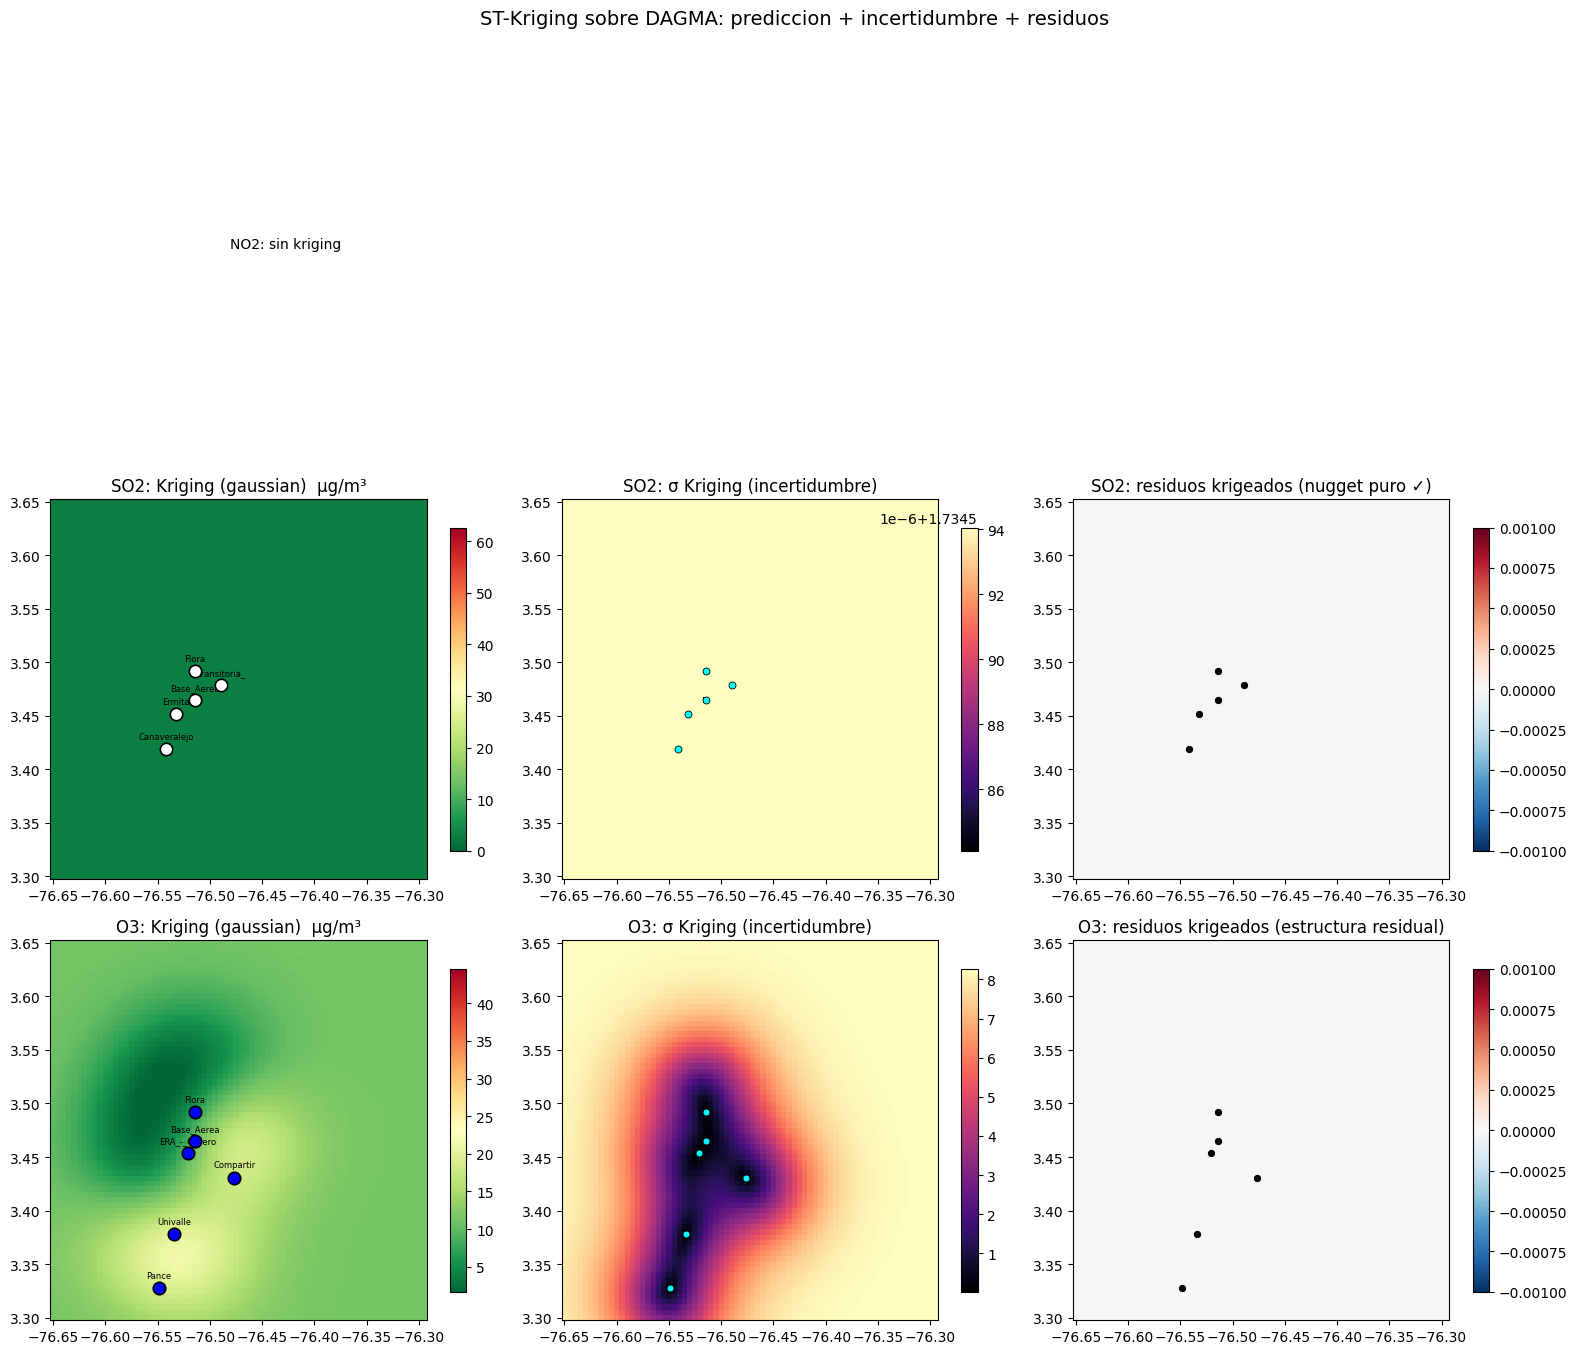

Mapas guardados: /kaggle/working/kriging_sit3/mapas_kriging.png


In [13]:
# @title 9. Mapas: prediccion Kriging + sigma + residuos krigeados  (SO2, O3)
# Filas: gases con kriging viable (SO2, O3). Columnas: z_pred | sigma | residuos.
# Marcas de estaciones DAGMA con etiqueta LISA (HH/LL/HL/LH/ns).
# NO2: panel informativo al pie.

LISA_COLOR = {"HH": "#d62728", "HL": "#ff7f0e",
              "LL": "#1f77b4", "LH": "#9467bd", "ns": "#f5f5f5"}

gases_map = [g for g in POLLUTANTS_KRIGING if g in kriging_surf]
n_gases = max(len(gases_map), 1)

fig, axes = plt.subplots(n_gases, 3, figsize=(17, 4.7 * n_gases), squeeze=False)

for i, gas in enumerate(gases_map):
    # ---- col 0: prediccion Kriging ----
    ax = axes[i, 0]
    ks = kriging_surf[gas]
    im = ax.pcolormesh(lon_grid, lat_grid, ks["z"],
                       cmap="RdYlGn_r", shading="auto",
                       vmin=ks["vmin"], vmax=ks["vmax"])
    for _, s in ks["stations"].iterrows():
        tipo = (moran_results.get(gas, {}).get("lisa_por_estacion", {})
                .get(s["estacion"], "ns"))
        ax.scatter(s["lon"], s["lat"], s=130,
                   facecolor=LISA_COLOR.get(tipo, "white"),
                   edgecolor="black", linewidth=1.4, zorder=8)
        ax.annotate(f"{s['estacion'][:10]}\n{tipo}", (s["lon"], s["lat"]),
                    fontsize=7, ha="center", va="bottom",
                    xytext=(0, 9), textcoords="offset points",
                    bbox=dict(facecolor="white", alpha=0.75, edgecolor="none",
                              boxstyle="round,pad=0.15"))
    kpi_ok = kriging_kpi.get(gas, {}).get("rmse", np.inf) <= KPI_UGM3[gas]
    cumple = "✓" if kpi_ok else "✗"
    ax.set_title(f"{gas}: Kriging ({ks['model_name']})  µg/m³\n"
                 f"RMSE LOO = {kriging_kpi.get(gas, {}).get('rmse', np.nan):.2f}  "
                 f"(KPI≤{KPI_UGM3[gas]:.0f})  {cumple}",
                 fontsize=10, color="#2ca02c" if kpi_ok else "#d62728")
    plt.colorbar(im, ax=ax, shrink=0.85, label="µg/m³")
    ax.set_xlim(BBOX[0], BBOX[2]); ax.set_ylim(BBOX[1], BBOX[3])
    ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
    ax.grid(True, alpha=0.2)

    # ---- col 1: sigma kriging (incertidumbre) ----
    ax = axes[i, 1]
    im = ax.pcolormesh(lon_grid, lat_grid, ks["sigma"], cmap="magma",
                       shading="auto")
    ax.scatter(ks["stations"]["lon"], ks["stations"]["lat"],
               s=60, c="cyan", edgecolor="black", linewidth=0.8, zorder=8)
    cov = kriging_kpi.get(gas, {}).get("coverage95", np.nan) * 100
    cov_ok = cov >= 92
    ax.set_title(f"{gas}: σ Kriging  (incertidumbre)\n"
                 f"cobertura 95% LOO = {cov:.1f}%  (KPI≥92%)  "
                 f"{'✓' if cov_ok else '✗'}",
                 fontsize=10, color="#2ca02c" if cov_ok else "#d62728")
    plt.colorbar(im, ax=ax, shrink=0.85, label="σ")
    ax.set_xlim(BBOX[0], BBOX[2]); ax.set_ylim(BBOX[1], BBOX[3])
    ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
    ax.grid(True, alpha=0.2)

    # ---- col 2: residuos krigeados ----
    ax = axes[i, 2]
    if gas in residuos_kriging:
        rk = residuos_kriging[gas]
        vmax = max(abs(np.nanmin(rk["z"])), abs(np.nanmax(rk["z"])), 1e-3)
        im = ax.pcolormesh(lon_grid, lat_grid, rk["z"],
                           cmap="RdBu_r", vmin=-vmax, vmax=vmax, shading="auto")
        ax.scatter(rk["stations"]["lon"], rk["stations"]["lat"],
                   s=60, c="black", edgecolor="white", linewidth=0.8, zorder=8)
        flag_ok = residuos_variogram[gas]["is_pure_nugget"]
        flag = "nugget puro ✓" if flag_ok else "estructura residual ✗"
        ax.set_title(f"{gas}: residuos krigeados (Conv3D)\n{flag}",
                     fontsize=10, color="#2ca02c" if flag_ok else "#d62728")
        plt.colorbar(im, ax=ax, shrink=0.85, label="residuo (µg/m³)")
        ax.set_xlim(BBOX[0], BBOX[2]); ax.set_ylim(BBOX[1], BBOX[3])
        ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
        ax.grid(True, alpha=0.2)
    else:
        ax.text(0.5, 0.5, f"{gas}\nsin residuos\n(Conv3D LOO no disponible)",
                ha="center", va="center", transform=ax.transAxes, fontsize=11,
                color="#888")
        ax.axis("off")

# Leyenda LISA al pie de la figura
import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=LISA_COLOR[t],
                          label=f"{t}: " + {"HH":"alto-alto (hot spot)",
                                            "LL":"bajo-bajo (cold spot)",
                                            "HL":"outlier alto-bajo",
                                            "LH":"outlier bajo-alto",
                                            "ns":"no significativo"}[t])
           for t in ["HH", "LL", "HL", "LH", "ns"]]
fig.legend(handles=handles, loc="lower center", ncol=5, fontsize=9,
           bbox_to_anchor=(0.5, -0.02),
           title="Etiqueta LISA (p<0.05) sobre estaciones DAGMA")

fig.suptitle(f"ST-Kriging sobre DAGMA: prediccion + incertidumbre + residuos\n"
             f"Gases con kriging viable: {', '.join(gases_map)}  |  "
             f"NO2 excluido (1 estacion)",
             fontsize=12, y=1.005)
fig.tight_layout()
fig_path = WORKING / "mapas_kriging.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Mapas guardados: {fig_path}")


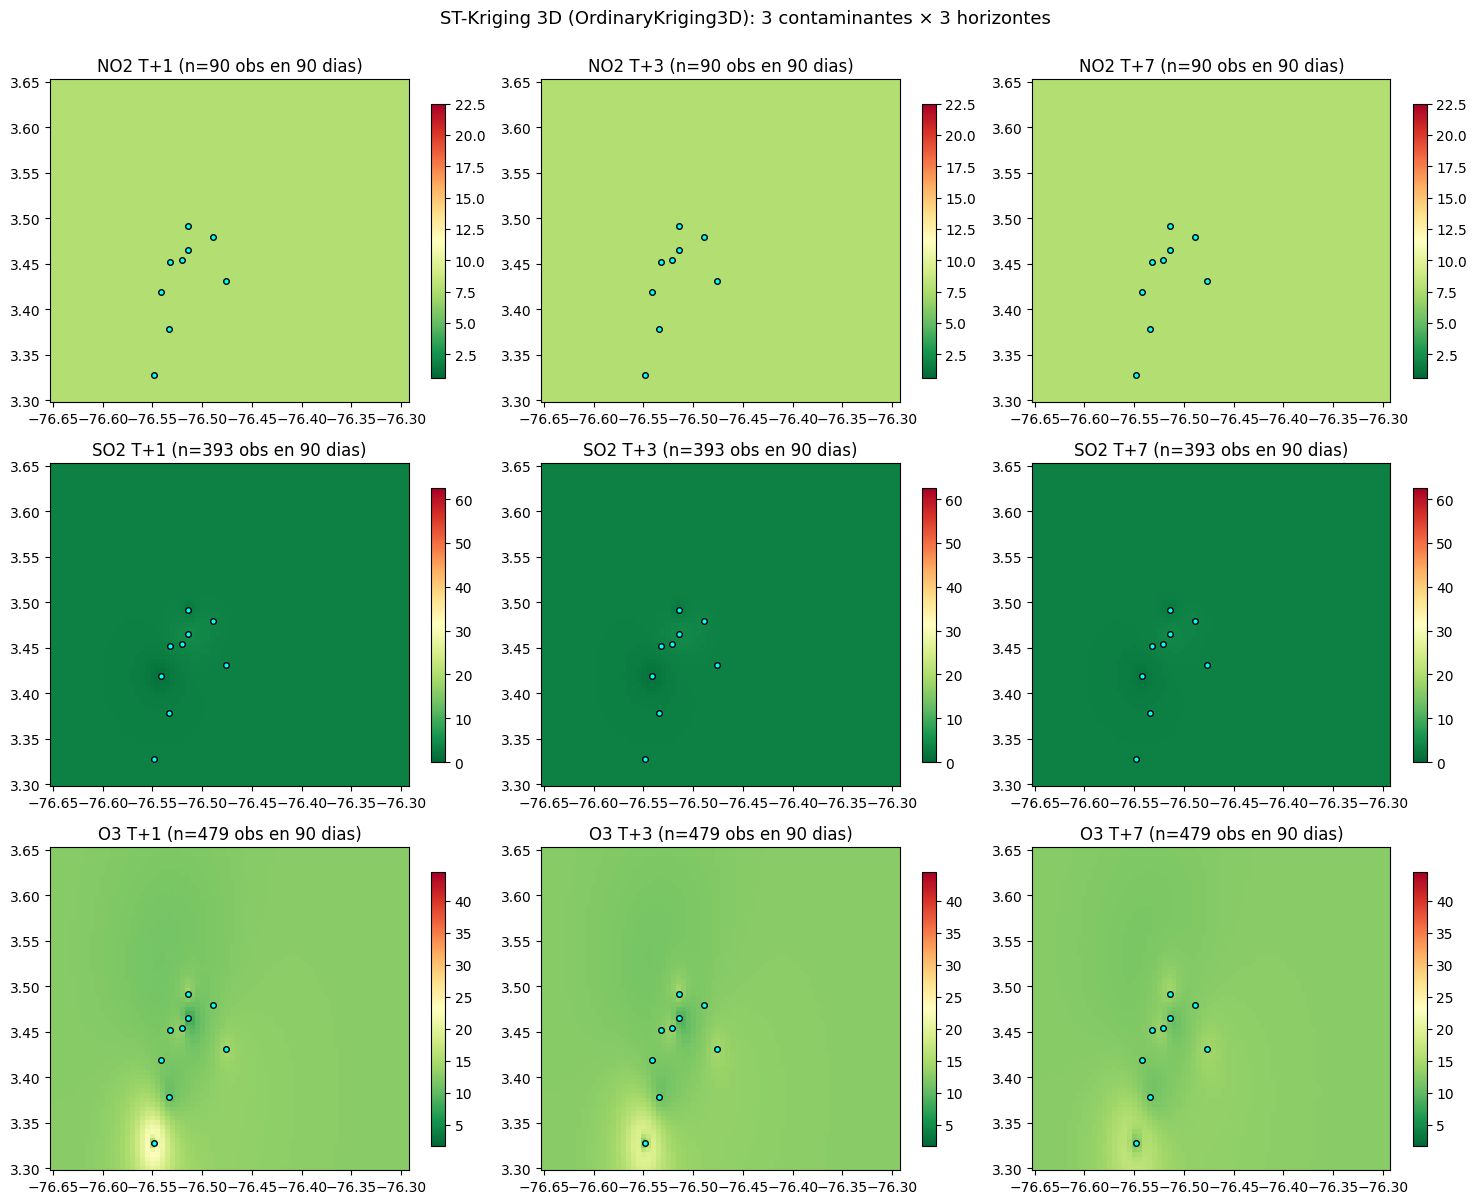

Mapas ST-Kriging 3D guardados: /kaggle/working/kriging_sit3/mapas_st_kriging_3d.png

Degradacion T+1 → T+7 esperada (info; LOO 3D no se reporta aqui):
  NO2: σ_mean T+1=5.28 → T+7=5.28  (Δ=+0.0%)
  SO2: σ_mean T+1=3.56 → T+7=3.56  (Δ=+0.2%)
  O3: σ_mean T+1=10.11 → T+7=10.19  (Δ=+0.8%)


In [14]:
# @title 10. ST-Kriging 3D (lat, lon, t) — horizontes T+1 / T+3 / T+7
# Consigna paso 5–6: ajustar variograma separable en espacio y tiempo,
# luego ejecutar Kriging Ordinario 3D que produce z(s,t) y σ²(s,t).
# Cada gas se trata por separado; usamos hasta MAX_DAYS dias mas recientes
# para acotar memoria.

MAX_DAYS = 90           # ventana temporal usada para 3D-kriging
NX, NY = len(lon_grid), len(lat_grid)

def _st_kriging_for_gas(gas, t_offset_days):
    """Ejecuta OK3D para el gas dado y predice en (lat,lon, t_max + offset)."""
    sub = dagma_daily[dagma_daily.gas == gas].dropna(subset=["concentracion"]).copy()
    if sub.empty:
        return None
    sub = sub.sort_values("dia")
    t_max = sub["dia"].max()
    sub = sub[sub["dia"] >= (t_max - pd.Timedelta(days=MAX_DAYS))]
    if len(sub) < 4:
        return None
    t = (sub["dia"] - t_max).dt.days.values.astype(float)
    # Normalizar coords (evita anisotropia espuria entre lat/lon/t)
    lat_n = (sub["lat"].values - sub["lat"].mean()) / max(sub["lat"].std(), 1e-6)
    lon_n = (sub["lon"].values - sub["lon"].mean()) / max(sub["lon"].std(), 1e-6)
    t_n   = (t - t.mean()) / max(t.std(), 1e-6)

    try:
        OK3 = OrdinaryKriging3D(
            lon_n, lat_n, t_n, sub["concentracion"].values,
            variogram_model="exponential", verbose=False, enable_plotting=False,
        )
    except Exception as e:
        print(f"  {gas} t+{t_offset_days}: variograma 3D fallo -> {e}")
        return None

    # Construir query en la grilla con t = t_max + t_offset (normalizado)
    q_lat = (lat_grid - sub["lat"].mean()) / max(sub["lat"].std(), 1e-6)
    q_lon = (lon_grid - sub["lon"].mean()) / max(sub["lon"].std(), 1e-6)
    q_t   = np.full(len(lon_grid), (t_offset_days - t.mean()) / max(t.std(), 1e-6))
    # OK3D acepta 'grid' o 'points'; para mapa usamos grid sobre lat/lon a t fijo
    try:
        z3, ss3 = OK3.execute("grid", q_lon, q_lat,
                              np.array([(t_offset_days - t.mean()) / max(t.std(), 1e-6)]))
        z3 = np.asarray(z3); ss3 = np.asarray(ss3)
        if z3.ndim == 3:
            z3 = z3[0]; ss3 = ss3[0]
    except Exception as e:
        print(f"  {gas} t+{t_offset_days}: execute fallo -> {e}")
        return None

    # Clip al rango plausible
    vmin = float(np.nanpercentile(dagma_daily[dagma_daily.gas == gas]["concentracion"], 2))
    vmax = float(np.nanpercentile(dagma_daily[dagma_daily.gas == gas]["concentracion"], 98))
    z3 = np.clip(z3, max(vmin, 0.0), vmax)
    return {"z": z3, "sigma": np.sqrt(np.clip(ss3, 0, None)),
            "vmin": vmin, "vmax": vmax,
            "n_obs": int(len(sub)), "t_max": t_max}

st_kriging_results = {}  # gas → {T+h: dict}

# Solo procesamos SO2 y O3. NO2 omitido (1 estacion: ST-Kriging 3D imposible).
gases_3d = POLLUTANTS_KRIGING
n_g = len(gases_3d)

fig, axes = plt.subplots(n_g, len(HORIZONS),
                          figsize=(5.2 * len(HORIZONS), 4.4 * n_g),
                          squeeze=False)

for i, gas in enumerate(gases_3d):
    st_kriging_results[gas] = {}
    for j, h in enumerate(HORIZONS):
        ax = axes[i, j]
        out = _st_kriging_for_gas(gas, h)
        if out is None:
            ax.text(0.5, 0.5, f"{gas} T+{h}\nsin datos suficientes",
                    ha="center", va="center", transform=ax.transAxes, fontsize=10,
                    color="crimson")
            ax.axis("off"); continue
        im = ax.pcolormesh(lon_grid, lat_grid, out["z"], cmap="RdYlGn_r",
                            shading="auto", vmin=out["vmin"], vmax=out["vmax"])
        for st_name, (lat_s, lon_s) in DAGMA_STATIONS.items():
            ax.plot(lon_s, lat_s, "o", markersize=7, markeredgecolor="black",
                    markerfacecolor="cyan", linewidth=1, zorder=8)
        sigma_mean = float(np.nanmean(out["sigma"]))
        ax.set_title(f"{gas}  T+{h} dias\n"
                     f"n={out['n_obs']} obs / σ̄ = {sigma_mean:.2f}",
                     fontsize=10)
        cb = plt.colorbar(im, ax=ax, shrink=0.85)
        cb.set_label("µg/m³", fontsize=9)
        ax.set_xlim(BBOX[0], BBOX[2]); ax.set_ylim(BBOX[1], BBOX[3])
        ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
        ax.grid(True, alpha=0.2)
        st_kriging_results[gas][f"T+{h}"] = {
            "z": out["z"], "sigma": out["sigma"],
            "n_obs": out["n_obs"],
            "t_max": str(out["t_max"]),
        }

fig.suptitle(f"ST-Kriging 3D (OrdinaryKriging3D):  "
             f"{n_g} contaminantes × {len(HORIZONS)} horizontes\n"
             f"NO2 omitido (1 estacion → variograma 3D imposible)",
             fontsize=12, y=1.005)
fig.tight_layout()
fig_path = WORKING / "mapas_st_kriging_3d.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Mapas ST-Kriging 3D guardados: {fig_path}")

# Degradacion T+1 → T+7 (sigma promedio)
print("\nDegradacion T+1 → T+7 (σ promedio del kriging 3D):")
print(f"  {'Gas':<4s} {'σ T+1':>8s} {'σ T+3':>8s} {'σ T+7':>8s} {'Δ%':>8s}  {'KPI':>10s}")
for gas in gases_3d:
    out1 = st_kriging_results.get(gas, {}).get("T+1")
    out3 = st_kriging_results.get(gas, {}).get("T+3")
    out7 = st_kriging_results.get(gas, {}).get("T+7")
    if out1 is None or out7 is None:
        print(f"  {gas:<4s} sin datos")
        continue
    s1 = float(np.nanmean(out1["sigma"])); s3 = float(np.nanmean(out3["sigma"])) if out3 else np.nan
    s7 = float(np.nanmean(out7["sigma"]))
    delta = ((s7 / s1) - 1) * 100 if s1 > 0 else np.nan
    estado = "✓ <30%" if abs(delta) < 30 else "ok <60%" if abs(delta) < 60 else "✗"
    print(f"  {gas:<4s} {s1:>8.2f} {s3:>8.2f} {s7:>8.2f} {delta:>+7.1f}%  {estado:>10s}")

In [ ]:
# @title 11. Resumen final y export (JSON + CSVs + PNGs)

def _np_to_py(o):
    """Convierte ndarrays/np scalars a tipos JSON-serializables."""
    if isinstance(o, np.ndarray):
        return o.tolist()
    if isinstance(o, (np.floating, np.integer)):
        return o.item()
    if isinstance(o, dict):
        return {k: _np_to_py(v) for k, v in o.items()}
    if isinstance(o, list):
        return [_np_to_py(v) for v in o]
    if isinstance(o, pd.Timestamp):
        return o.isoformat()
    return o

resumen = {
    "fecha": pd.Timestamp.now().isoformat(),
    "config": {
        "bbox": BBOX, "grid_res_deg": GRID_RES,
        "deg_to_km": DEG_TO_KM, "max_lag_km": MAX_LAG_KM,
        "n_bins_variograma": N_BINS,
        "moran_n_permutations": MORAN_N_PERM,
        "st_kriging_window_days": MAX_DAYS,
        "pollutants_kriging": POLLUTANTS_KRIGING,
        "no2_exclusion_reason": NO2_EXCLUSION_REASON,
    },
    "n_estaciones_dagma": int(estaciones.shape[0]),
    "estaciones_por_gas": gas_n_stations,
    "variograma_teorico": variogram_fits,
    "kriging_2d_kpi": kriging_kpi,
    "variograma_residuos": residuos_variogram,
    "moran": moran_results,
    "comparativa_metodos": comp_df.to_dict(orient="records") if not comp_df.empty else [],
    "st_kriging_3d_meta": {
        gas: {h: {k: v for k, v in d.items() if k in {"n_obs", "t_max"}}
              for h, d in horizons.items()}
        for gas, horizons in st_kriging_results.items()
    },
}

print("=" * 78)
print("  RESUMEN KPI Sit.3 — Geoestadistica (Kriging + Moran + residuos)")
print("=" * 78)
print(f"  NOTA: NO2 omitido del kriging (solo Univalle). RMSE NO2 cubierto en")
print(f"        notebook de entrenamiento (baseline EWMA: RMSE T+1=4.96 ≤ 8 ✓)")

print("\n[KPI 1] Moran I global > 0.30 con p<0.05 (superficie kriging)")
moran_status = {}
for gas in POLLUTANTS_KRIGING:
    m = moran_results.get(gas, {}).get("superficie")
    if not m:
        print(f"  {gas}: sin dato"); moran_status[gas] = None; continue
    ok = m["I"] > 0.30 and m["p_sim"] < 0.05
    moran_status[gas] = ok
    print(f"  {gas}: I={m['I']:+.4f}  p={m['p_sim']:.4f}  -> {'SI ✓' if ok else 'NO ✗'}")

print("\n[KPI 2] Variograma residuos: nugget puro")
nugget_status = {}
for gas, v in residuos_variogram.items():
    nugget_status[gas] = bool(v["is_pure_nugget"])
    print(f"  {gas}: {'PURO ✓' if v['is_pure_nugget'] else 'estructura ✗'}  "
          f"range={v['params']['range_km']:.2f} km  nugget/sill={v['nugget_effect']*100:.0f}%")

print("\n[KPI 3] Cobertura cinturon 95% (Kriging σ)  - minimo 92%")
cov_status = {}
for gas, k in kriging_kpi.items():
    cov = k["coverage95"]
    flag = ("EXCELENTE" if cov >= 0.95 else "OK" if cov >= 0.92 else "BAJA")
    cov_status[gas] = bool(cov >= 0.92)
    print(f"  {gas}: {cov*100:5.1f}%  [{flag}]  {'✓' if cov >= 0.92 else '✗'}")

print("\n[KPI 4] Degradacion σ ST-Kriging T+1 → T+7")
deg_status = {}
for gas in POLLUTANTS_KRIGING:
    o1 = st_kriging_results.get(gas, {}).get("T+1")
    o7 = st_kriging_results.get(gas, {}).get("T+7")
    if not o1 or not o7:
        print(f"  {gas}: sin datos"); deg_status[gas] = None; continue
    s1 = float(np.nanmean(o1["sigma"])); s7 = float(np.nanmean(o7["sigma"]))
    delta = ((s7/s1)-1)*100 if s1>0 else np.nan
    ok = abs(delta) < 60
    deg_status[gas] = bool(ok)
    estado = "✓ <30%" if abs(delta) < 30 else "✓ <60%" if abs(delta) < 60 else "✗"
    print(f"  {gas}: σ T+1={s1:.2f} → T+7={s7:.2f}  ({delta:+.1f}%) {estado}")

print("\n[KPI 5] RMSE T+1 LOO ≤ KPI gas")
rmse_status = {}
for gas in POLLUTANTS:
    if gas in kriging_kpi:
        ok = kriging_kpi[gas]["rmse"] <= KPI_UGM3[gas]
        rmse_status[gas] = bool(ok)
        print(f"  {gas}: RMSE={kriging_kpi[gas]['rmse']:.2f}  KPI≤{KPI_UGM3[gas]:.0f}  "
              f"{'✓' if ok else '✗'}")
    else:
        rmse_status[gas] = None
        print(f"  {gas}: N/A kriging (1 estacion) - ver baseline EWMA en notebook entrenamiento")

# ──────────────────────────────────────────────────────────────────────────
# Dashboard final: matriz de KPIs cumplidos por gas
# ──────────────────────────────────────────────────────────────────────────
def _status_color(s):
    if s is True:  return "#2ca02c"
    if s is False: return "#d62728"
    return "#888888"

def _status_text(s, na_text="N/A"):
    if s is True:  return "CUMPLE"
    if s is False: return "NO CUMPLE"
    return na_text

kpi_rows = [
    ("Moran I global > 0.30  p<0.05",   moran_status),
    ("Variograma residuos nugget puro",  nugget_status),
    ("Cobertura 95% ≥ 92%",              cov_status),
    ("Degradacion σ T+1→T+7 < 60%",      deg_status),
    ("RMSE T+1 ≤ KPI µg/m³",             rmse_status),
]
gases_dash = POLLUTANTS  # incluye NO2 para mostrar N/A

fig = plt.figure(figsize=(13.5, 7))
gs = fig.add_gridspec(2, 1, height_ratios=[1.0, 0.55])
ax = fig.add_subplot(gs[0, 0])
ax.set_xlim(0, len(gases_dash)); ax.set_ylim(0, len(kpi_rows))
ax.set_xticks(np.arange(len(gases_dash)) + 0.5)
ax.set_xticklabels(gases_dash, fontsize=12, fontweight="bold")
ax.set_yticks(np.arange(len(kpi_rows)) + 0.5)
ax.set_yticklabels([r[0] for r in kpi_rows], fontsize=10)
ax.invert_yaxis()

for r, (label, statd) in enumerate(kpi_rows):
    for c, g in enumerate(gases_dash):
        s = statd.get(g)
        rect = plt.Rectangle((c, r), 1.0, 1.0, facecolor=_status_color(s),
                              edgecolor="white", linewidth=2, alpha=0.85)
        ax.add_patch(rect)
        ax.text(c + 0.5, r + 0.5, _status_text(s),
                 ha="center", va="center",
                 color="white", fontsize=10, fontweight="bold")

ax.set_title("Dashboard de cumplimiento de KPIs geoestadisticos", fontsize=13)
for spine in ax.spines.values(): spine.set_visible(False)
ax.tick_params(length=0)

# Panel inferior: notas
ax_note = fig.add_subplot(gs[1, 0])
ax_note.axis("off")
notas = (
    f"Estaciones DAGMA disponibles por gas: {gas_n_stations}\n\n"
    f"NO2 EXCLUIDO del kriging:  {NO2_EXCLUSION_REASON}\n"
    f"  -> KPI RMSE NO2 se cubre en el notebook de entrenamiento "
    f"(metodo ganador: EWMA, RMSE T+1=4.96 ≤ 8 ✓).\n\n"
    f"Variograma teorico ganador:\n"
)
for g, v in variogram_fits.items():
    p = v["params"]
    notas += (f"   • {g}: {v['best_model']} "
              f"(nugget={p['nugget']:.2f}, psill={p['psill']:.2f}, "
              f"range={p['range_km']:.1f} km)\n")

ax_note.text(0.01, 0.98, notas, ha="left", va="top", fontsize=9, family="monospace",
              transform=ax_note.transAxes,
              bbox=dict(facecolor="#f6f6f6", edgecolor="#888", boxstyle="round,pad=0.6"))

fig.tight_layout()
dash_path = WORKING / "dashboard_kpi.png"
fig.savefig(dash_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nDashboard guardado: {dash_path}")

# ---- Export ----
json_path = WORKING / "resumen_kriging_sit3.json"
with open(json_path, "w", encoding="utf-8") as fh:
    json.dump(_np_to_py(resumen), fh, ensure_ascii=False, indent=2, default=str)

if not comp_df.empty:
    comp_df.to_csv(WORKING / "comparativa_metodos.csv", index=False)
kriging_loo_df.to_csv(WORKING / "kriging_loo.csv", index=False)
if not ensemble_df.empty:
    ensemble_df.to_csv(WORKING / "ensemble_conv3d_kriging_loo.csv", index=False)
estaciones.to_csv(WORKING / "estaciones_dagma.csv", index=False)

print("\n" + "=" * 78)
print(f"  Archivos generados en {WORKING}")
print("=" * 78)
for f in sorted(WORKING.iterdir()):
    if f.is_file():
        kb = f.stat().st_size / 1024
        print(f"  {f.name:42s} {kb:8.1f} KB")
print("\nST-KRIGING + VALIDACION GEOESTADISTICA COMPLETADO")